# DSM Assignment 2
Please pay attention to the following instructions:
1. Please follow carefully the steps outlined in the assignment. If you cannot solve an exercise and this hinders continuing with subsequent exercises, try to find a way to work around it and give a clear explanation for the solution you have chosen.
2. Submit your work in the form of a Jupyter notebook via Canvas, before the deadline. Your notebook should not give errors when executed with `Run All`.

# IMPORTANT: RESTRICTION ON ALLOWED LIBRARIES!!!
You are **NOT** allowed to use any scikit-learn models and functions, except `Kfold` (possibly needed in part 2) and `datasets` (needed in part 2). Material from the computer classes, including the solutions, can be used and copied freely and without penalty.

## Part 0: importing the relevant libraries

**Exercise 1:** import all the libraries you are using in this notebook.

In [1]:
import pickle

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.model_selection import KFold
#========================================
from itertools import combinations_with_replacement
from scipy import stats

## Part 1: classification using LDA
In this part of the assignment, we will apply classification to the `moons` data generating process of scikit-learn, which is imported and visualized in the cell below.

Hint: you may use/copy material of the computer classes (including the solutions) freely and without penalty.

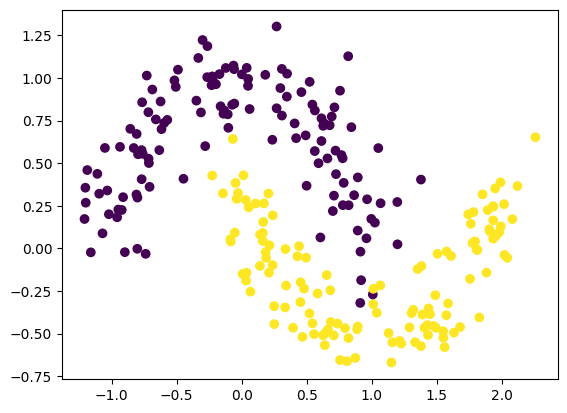

In [2]:
# DO NOT CHANGE THIS CELL!!! #
X_moons, y_moons = datasets.make_moons(n_samples = 256, noise = .15)
plt.scatter(X_moons[:,0], X_moons[:,1], c=y_moons);

**Exercise 2:** use Linear Discriminant Analysis (LDA) to determine the prediction regions, based on the classification dataset given by `X_moons` and `y_moons`. Your solution should consist of two parts:
* implementation of the method.
* visualization of the prediction regions.

Note: your are **not** allowed to use any training methods/functions from existing packages or modules.

In [3]:
def visualize_prediction_regions(X, y, predict, title):

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    # Prediction for each point
    Z = predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=.45, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.coolwarm)
    plt.title(title)
    plt.show()

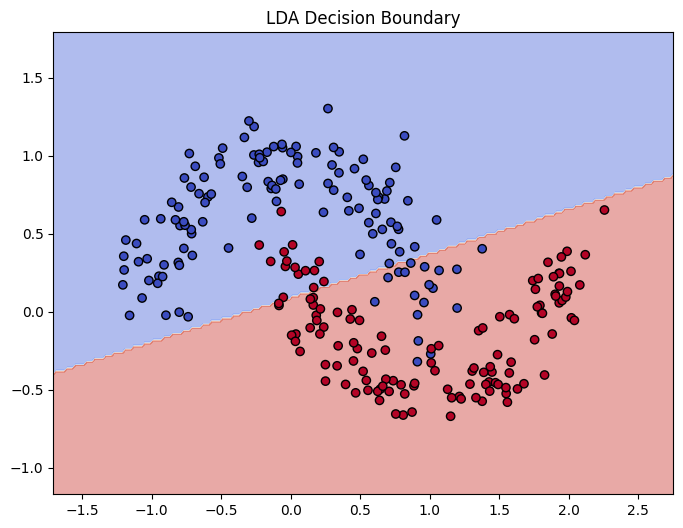

LDA Training accuracy: 0.8711


In [4]:
# Function to train LDA model
def train_LDA(X,y):
    X0 = X[y==0]
    X1 = X[y==1]

    # Calculate means
    mu0 = np.mean(X0, axis=0)
    mu1 = np.mean(X1, axis=0)

    Sigma0 = np.cov(X0.T)
    Sigma1 = np.cov(X1.T)

    #Sigma = (Sigma0*len(X0) + Sigma1*len(X1)) / (len(X0) + len(X1))
    Sigma = (Sigma0*len(X0) + Sigma1*len(X1)) / len(X1)

    n_features = X.shape[1]
    beta = np.zeros(n_features)
    beta_0 = 0

    beta = np.linalg.inv(Sigma).dot(mu1 - mu0)
    beta_0 = -0.5 * mu1.T.dot(np.linalg.inv(Sigma)).dot(mu1) + 0.5 * mu0.T.dot(np.linalg.inv(Sigma)).dot(mu0) + np.log(len(X1)/len(X0))

    def predict(X):
        return (X.dot(beta) + beta_0 > 0).astype(int)
    return predict

# Train LDA model
LDA_predict = train_LDA(X_moons, y_moons)

visualize_prediction_regions(X_moons, y_moons, LDA_predict, "LDA Decision Boundary")

y_pred = LDA_predict(X_moons)
accuracy = np.mean(y_pred == y_moons)
print(f"LDA Training accuracy: {accuracy:.4f}")

**Exercise 3:** in the above exercise, we see that LDA performs poorly on this dataset. However, with some small adjustments one can get a much better prediction accuracy. Repeat all the steps of the previous exercise, but now for LDA with an increased feature space. Choose your derived features smartly.

Note: your are **not** allowed to use any training methods/functions from existing packages or modules.

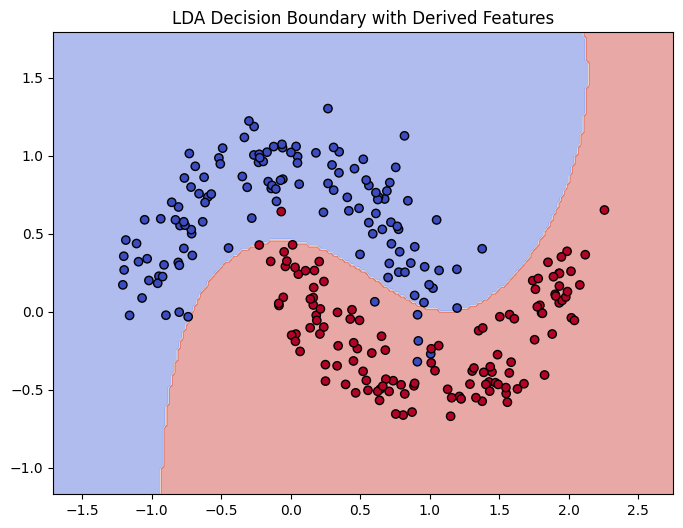

Accuracy: 0.9766


In [5]:
# Increase feature space
def add_features(X):
    x1, x2 = X[:, 0], X[:, 1]
    return np.column_stack([
        X,
        x1**2, x2**2,  
        x1*x2,         
        x1**3, x2**3,  
        np.exp(-(x1**2 + x2**2)),  
        np.sin(x1), np.cos(x2) 
    ])

def train_enhanced_lda(X, y):
    # Add derived features
    X_enhanced = add_features(X)
    
    # Separate the data by class
    X0 = X_enhanced[y == 0]
    X1 = X_enhanced[y == 1]
    
    # Calculate means
    mu0 = np.mean(X0, axis=0)
    mu1 = np.mean(X1, axis=0)
    
    # Calculate covariance matrices
    Sigma0 = np.cov(X0.T)
    Sigma1 = np.cov(X1.T)
    
    # Shared covariance matrix
    Sigma = (Sigma0 * len(X0) + Sigma1 * len(X1)) / len(X_enhanced)
    
    # Add regularization
    Sigma += np.eye(Sigma.shape[0]) * 1e-2 # l2 regularization, change to find a proper result
    
    # Calculate weights and bias
    beta = np.linalg.inv(Sigma).dot(mu1 - mu0)
    beta_0 = -0.5 * mu1.T.dot(np.linalg.inv(Sigma)).dot(mu1) + 0.5 * mu0.T.dot(np.linalg.inv(Sigma)).dot(mu0) + np.log(len(X1) / len(X0))
    
    # Define predictor function
    def predict(X):
        X_enhanced = add_features(X)
        return (X_enhanced.dot(beta) + beta_0 > 0).astype(int)
    
    return predict


# Train enhanced LDA model
enhanced_lda_predict = train_enhanced_lda(X_moons, y_moons)

# Visualize prediction regions
visualize_prediction_regions(X_moons, y_moons, enhanced_lda_predict, title="LDA Decision Boundary with Derived Features")

# Calculate and print accuracy
y_pred = enhanced_lda_predict(X_moons)
accuracy = np.mean(y_pred == y_moons)
print(f"Accuracy: {accuracy:.4f}")

The accuracy was enhance

## Part 2: modeling competition
This part of the assignment consists of a modeling competition. In the cell below a dataset `data_train` is loaded, consisting of 100 independent observations with 80-dimensional continuous input features `data_train.X` and a 1-dimensional continuous target variable `data_train.y`.

The goal is to use this data to train a model with the best generalization performance. The names of the students with the 3 best performing models will be announced.

This part of the assignment consists of three subsections:
* *analysis*: in this subsection you should analyze the data and try different modeling techniques and compare them in the correct way. You can use as many cells (code, markdown) as you need. Make sure your analysis is structured logically. It should be readable like a report or essay.
* *best model*: based on your analysis in the previous subsection, you have identified a best model. This should be defined in the code cell of this subsection, in the form of a class called `Model`.
* *generalization performance*: in this subsection the generalization performance of your best model `Model` is assessed. This is done with a test set consisting of 20000 independent datapoints that are drawn from the same distribution as the observations in `data_train`. Students do not have access to this test set.

Details of the modeling competition:
* you are only allowed to use methods that have been discussed in this course.
* the cell in the subsection *generalization performance* should **NOT** be changed!!! Not that if the test set file `data_test.pkl` is not available (which is the case for students), a file called `data_test_FAKE.pkl` is loaded instead. The data in this file has exactly the same structure as the data in `data_test.pkl`, but the actual numbers are completely random. You can use this file to test whether the cell in the subsection *generalization performance* runs without errors.

In [4]:
# DO NOT CHANGE THIS CELL!!! #
class Data():

    def __init__(self, n_samples=100, random_state=None, dgp=None):

        self.n_samples = n_samples
        self.random_state = random_state
        self.dgp = dgp
        if self.dgp is not None:
            self.X, self.y = self.dgp.generate_data(self.n_samples, self.random_state)

with open('data/data_train.pkl', 'rb') as f:
    data_train = pickle.load(f)

#### Analysis
Use the space below for your analysis of this modeling problem. You can use as many cells (code, markdown) as you need. Make sure your analysis is structured logically. It should be readable like a report or essay.

First, we extracts the feature matrix and target vector from the training datase.

Shape of features X: (100, 80)
Shape of target y: (100, 1)
Mean of features: [-0.0049601   0.02298433  0.02454583  0.00929951  0.01919348]
Std of features: [0.26868377 0.13006941 0.11417552 0.14965025 0.1792746 ]


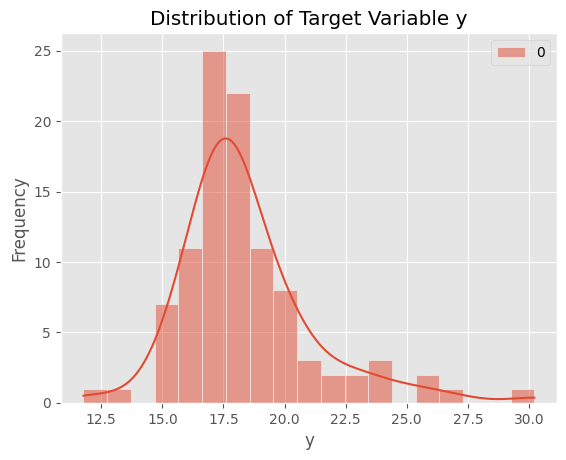

Mean of y: 18.444849817026874
Std of y: 2.7339777092552264


In [5]:
X, y = data_train.X, data_train.y 
print("Shape of features X:", X.shape)
print("Shape of target y:", y.shape)
print("Mean of features:", np.mean(X[:, :5], axis=0))
print("Std of features:", np.std(X[:, :5], axis=0))
# Plot the distribution of the target variable
plt.style.use('ggplot')
sns.histplot(y, kde=True)
plt.title('Distribution of Target Variable y')
plt.xlabel('y')
plt.ylabel('Frequency')
plt.show()
print("Mean of y:", np.mean(y))
print("Std of y:", np.std(y))


**Data Inspection**

The dataset contains 100 samples with 80 features. By inspecting the feature matrix, we observe that the feature means are close to zero, suggesting that the data has been approximately centered. However, the standard deviations differ across features, with values ranging between 0.1–0.3 for the first few variables. This indicates that the dataset has not been fully standardized, which may affect models that are sensitive to scaling (e.g., PCA, regression, kernel methods). Therefore, preprocessing steps such as feature standardization may be necessary before applying different training model.

**Methodology**

Since the dataset is relatively small (100 samples), splitting into separate training and validation sets would further reduce the effective training size and may lead to unstable results. Instead, we adopt k-fold cross-validation (with $𝑘=10$) as our evaluation strategy.

Each fold uses 90 samples for training and 10 samples for validation. This ensures that all samples are used for both training and validation across folds.

Model performance is assessed by computing the RMSE for each fold, and the average RMSE across folds is reported.


In [6]:
def standardize_data(data, mean=None, std=None): 
    if mean is None:
        mean = np.mean(data.X, axis=0)
    if std is None:
        std = np.std(data.X, axis=0)
        std[std == 0] = 1.0   # avoid division by zero
    
    data.X = (data.X - mean) / std
    return mean, std


mean_X, std_X = standardize_data(data_train)

X, y = data_train.X, data_train.y 

print("Shape of features X:", X.shape)
print("Shape of target y:", y.shape)
print("Mean of features:", np.mean(X[:, :5], axis=0))
print("Std of features:", np.std(X[:, :5], axis=0))

Shape of features X: (100, 80)
Shape of target y: (100, 1)
Mean of features: [ 1.11022302e-17 -3.99680289e-17 -1.36002321e-17 -1.77635684e-17
  5.21804822e-17]
Std of features: [1. 1. 1. 1. 1.]


#### Note:
This is a regression task with continuous target y. classification methods such as Linear Discriminant Analysis (LDA) and Logistic Regression are not applicable. Instead, we focus on regression-based approaches.
Due to the relatively small dataset size (100 samples), SGD is not the preferred optimization method. SGD is typically more effective in large-scale or online learning scenarios where incremental updates are beneficial. In this context, closed-form solutions or batch optimization methods offer greater stability and faster convergence.

Number of components to explain 90% variance: 3
Number of components to explain 95% variance: 10
Number of components to explain 98% variance: 23


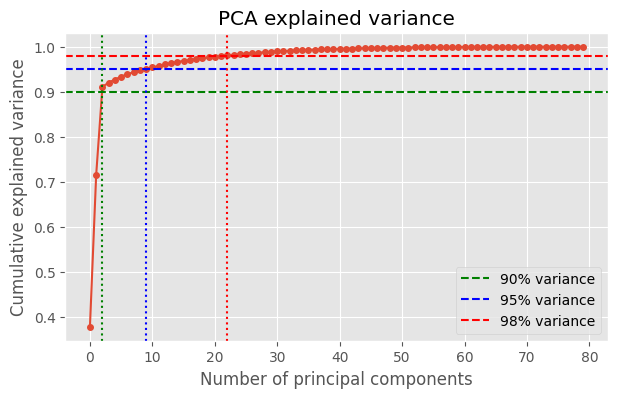

In [7]:
# Compute covariance matrix
X_centered = X - np.mean(X, axis=0)
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

explained_variance = (S**2) / np.sum(S**2)
cumulative_variance = np.cumsum(explained_variance)

C90 = np.searchsorted(cumulative_variance, 0.9) + 1
C95 = np.searchsorted(cumulative_variance, 0.95) + 1
C98 = np.searchsorted(cumulative_variance, 0.98) + 1
print(f"Number of components to explain 90% variance: {C90}")
print(f"Number of components to explain 95% variance: {C95}")
print(f"Number of components to explain 98% variance: {C98}")

 
plt.figure(figsize=(7, 4))
plt.plot(cumulative_variance, marker='o', markersize=4)
plt.axhline(y=0.90, color='g', linestyle='--', label='90% variance')
plt.axhline(y=0.95, color='b', linestyle='--', label='95% variance')
plt.axhline(y=0.98, color='r', linestyle='--', label='98% variance')
plt.axvline(x=C90-1, color='g', linestyle=':')
plt.axvline(x=C95-1, color='b', linestyle=':')
plt.axvline(x=C98-1, color='r', linestyle=':')
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA explained variance")
plt.legend()
plt.grid(True)
plt.show()

The PCA analysis reveals that the dataset exhibits a strong low-dimensional structure, as the first three principal components already account for more than 95% of the total variance. This indicates that although the dataset originally has 80 features, most of the information relevant for modeling lies in just a few linear combinations of them.
Therefore, dimension reduction is highly beneficial in this setting. Using only the top components(3-10 or increase the range to 23) in a regression model should greatly reduce the risk of overfitting while retaining nearly all relevant information.

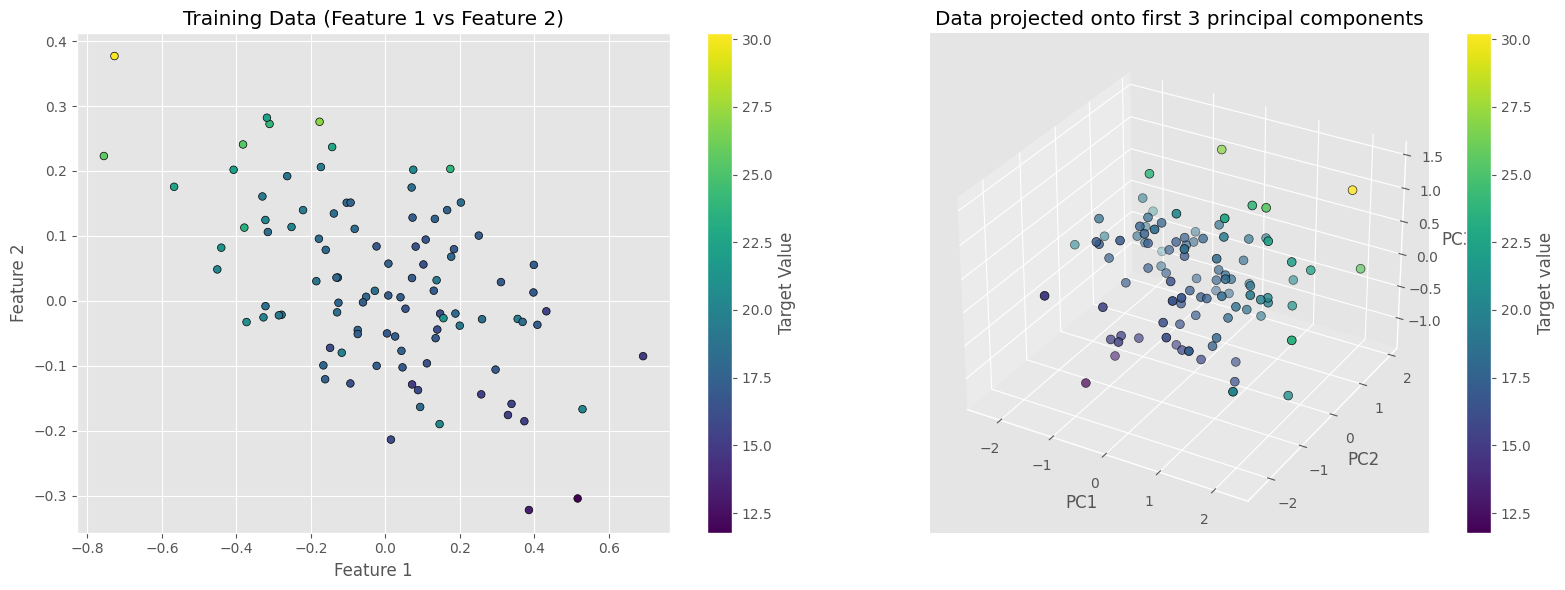

In [12]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(16, 6))

# 2D scatter (Feature 1 vs Feature 2)
ax1 = fig.add_subplot(1, 2, 1)
sc1 = ax1.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k', s=30)
ax1.set_title('Training Data (Feature 1 vs Feature 2)')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
plt.colorbar(sc1, ax=ax1, label='Target Value')

# 3D scatter (first 3 PCs)
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
PCs3 = X_centered @ Vt.T[:, :3]
sc2 = ax2.scatter(PCs3[:, 0], PCs3[:, 1], PCs3[:, 2], c=y, cmap='viridis', edgecolor='k', s=40)
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.set_zlabel("PC3")
ax2.set_title("Data projected onto first 3 principal components")
fig.colorbar(sc2, ax=ax2, label="Target value")

plt.tight_layout()
plt.show()


A 2D scatter plot using only two features (Feature 1 vs Feature 2) is insufficient because it ignores most of the 80-dimensional structure. To better captre the structure of the data, base on previous analysis, we project it into the first three principal component(PC1, PC2, PC3), which together explain about 95% of the total variance. By visualizing the dataset is concentrated along a few directions.<br>

The 3D scatter plot shows that the samples occupy a low-dimensional subspace within the original 80-dimensional feature space. Patterns, clusters, or trends related to the target variable are more visible in this PCA projection than in the 2D plot of arbitrary features. This indicates that most of the information in X can be captured using just a few principal components, which is useful for dimensionality reduction and for reducing the risk of overfitting in regression models.

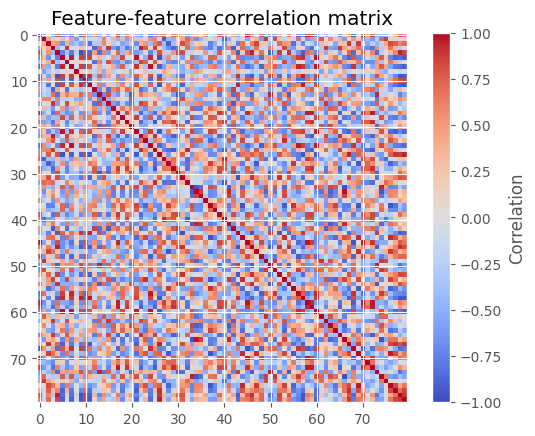

In [7]:
cov_matrix = np.corrcoef(X.T)

plt.imshow(cov_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.title("Feature-feature correlation matrix")
plt.show()





The next phase will involve fitting polynomial regression models and evaluating their performance using cross-validation. Regularization techniques such as Ridge and Lasso will also be explored to improve generalization and robustness.


In [8]:
# implementation of train_test_split, evaluate_model_cv, plot_for_analysis_model, PCAWrapper
class DataWrapper:
    def __init__(self, X, y):
        self.X = X
        self.y = y

def train_test_split(data, test_size=0.2, random_state=42):
    np.random.seed(random_state)
    n_samples = data.X.shape[0]
    indices = np.random.permutation(n_samples)
    test_size = int(n_samples * test_size)
    test_indices = indices[:test_size]
    train_indices = indices[test_size:]

    X_train, y_train = data.X[train_indices], data.y[train_indices]
    X_val, y_val = data.X[test_indices], data.y[test_indices]

    return DataWrapper(X_train, y_train), DataWrapper(X_val, y_val)

def plot_for_analysis_model(y_true, y_pred, color='#274E7A'):
    
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    residuals = y_true - y_pred

    plt.figure(figsize=(15, 5))

    # 1. Predicted vs Actual
    plt.subplot(131)
    plt.scatter(y_true, y_pred, alpha=0.5, color=color)
    plt.plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()], 'r--', lw=2)
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title('Predicted vs Actual')

    # 2. Residual Plot
    plt.subplot(132)
    plt.scatter(y_pred, residuals, alpha=0.5, color=color)
    plt.hlines(y=0, xmin=y_pred.min(), xmax=y_pred.max(),
               colors='r', linestyles='--')
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.title('Residual Plot')

    # 3. Error Distribution
    plt.subplot(133)
    sns.histplot(residuals, kde=True, color=color)
    plt.xlabel('Prediction Error')
    plt.title('Distribution of Errors')

    plt.tight_layout()
    plt.show()

def evaluate_model_cv(model_class, data, k=10, **model_kwargs):
    
    kfold = KFold(n_splits=k, shuffle=True, random_state=42)

    mse_scores = []
    y_val_all, y_val_pred_all = [], []

    for train_idx, val_idx in kfold.split(data.X, data.y):
       
        X_train, X_val = data.X[train_idx], data.X[val_idx]
        y_train, y_val = data.y[train_idx], data.y[val_idx]
        y_train = np.array(y_train).reshape(-1)

        data_train = DataWrapper(X_train, y_train)

        model = model_class(**model_kwargs)
        model.fit(data_train)

        y_pred = model.predict(X_val)
        y_pred = np.array(y_pred).reshape(-1)   
        y_val = np.array(y_val).reshape(-1)     

        mse = np.mean((y_val - y_pred) ** 2)
        mse_scores.append(mse)

        y_val_all.append(y_val)
        y_val_pred_all.append(y_pred)
        
    y_val_all = np.concatenate(y_val_all).reshape(-1)
    y_val_pred_all = np.concatenate(y_val_pred_all).reshape(-1)

    mean_mse = np.mean(mse_scores)
    rmse = np.sqrt(np.mean((y_val_all - y_val_pred_all) ** 2))
    std_mse = np.std(mse_scores)
    
    print(f"Average MSE: {mean_mse:.4f}")
    print(f"Standard deviation of MSE: {std_mse:.4f}")
    print(f"The RMSE: {rmse:.4f}")

    return {
        "mean_mse": mean_mse,
        "std_mse": std_mse,
        "rmse": rmse,
        "y_true": y_val_all,
        "y_pred": y_val_pred_all
    }
# Dimensionality reduction was performed using Principal Component Analysis (PCA) 
# This step helps mitigate multicollinearity and improves computational efficiency before feeding the data into downstream models.
class PCAWrapper:
    def __init__(self, n_components):
        self.n_components = n_components
        self.mean_ = None
        self.std_ = None
        self.Vt = None  # top eigenvectors

    def fit(self, X):
        # Standardize
        self.mean_ = np.mean(X, axis=0)
        self.std_ = np.std(X, axis=0)
        X_scaled = (X - self.mean_) / self.std_

        # SVD
        U, S, Vt = np.linalg.svd(X_scaled, full_matrices=False)
        self.Vt = Vt[:self.n_components, :]
        return self

    def transform(self, X):
        X_scaled = (X - self.mean_) / self.std_
        return X_scaled @ self.Vt.T

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

Average MSE: 31.1350
Standard deviation of MSE: 24.8935
The RMSE: 5.5799


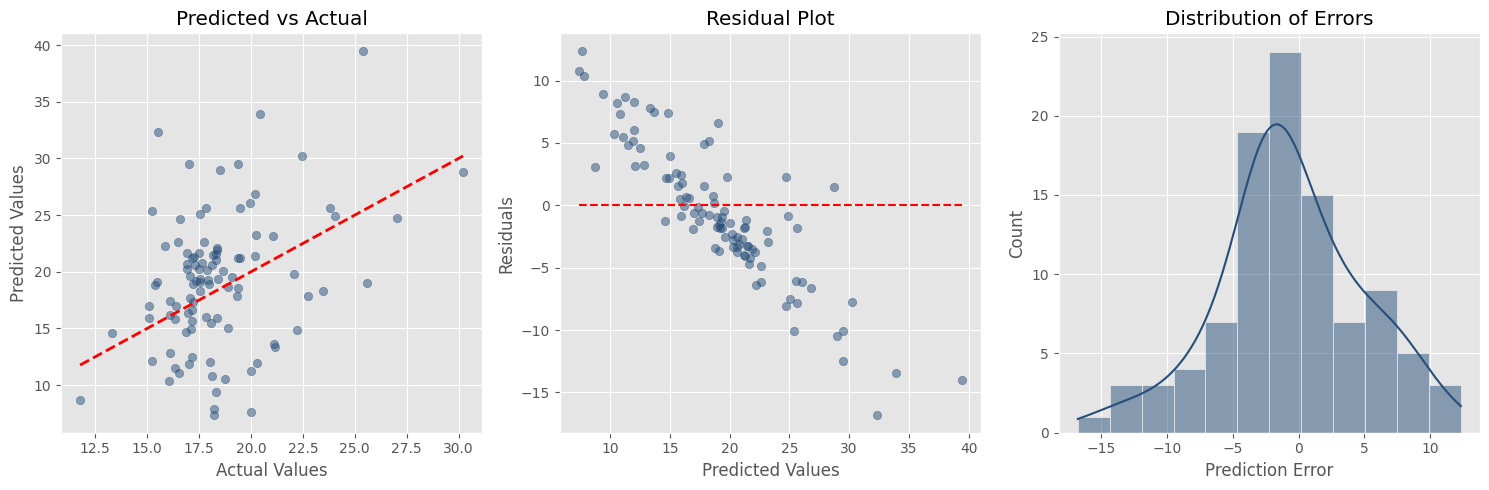

In [49]:
class LinearRegression:
    def __init__(self, **kwargs):
        self.beta = None
        self.mean_ = None
        self.std = None

    def fit(self, data):
        X, y = data.X, data.y
        self.mean_ = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)
        self.std[self.std == 0] = 1.0  
        X = (X - self.mean_) / self.std
        # Add a bias (intercept) term to the feature matrix
        X_b = np.c_[np.ones(X.shape[0]), X]
        self.beta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
        

    def predict(self, X):
        X = (X - self.mean_) / self.std
        X_b = np.c_[np.ones(X.shape[0]), X]
        return X_b @ self.beta

results = evaluate_model_cv(LinearRegression, data_train, k=10)

plot_for_analysis_model(results["y_true"], results["y_pred"])


The baseline Linear Regression model resulted in an average MSE of 31.14 and an RMSE of 5.58, which indicates relatively poor predictive performance. From the scatter plot of predicted versus actual values, we observe that the points are distributed rather chaotically and do not align well along the ideal prediction line. Moreover, in the residual plot, the residuals show a noticeable trend from the top-left to the bottom-right instead of being randomly scattered around zero. This pattern suggests that the linear model is unable to fully capture the underlying relationship in the data. Therefore, extending the model with polynomial features could help to better represent potential nonlinearities and improve the fit.

In [85]:
class PolynomialModel():

    def __init__(self, **model_kwargs):
        self.degree = model_kwargs.get('degree', 2)
        self.method = model_kwargs.get('method', 'ols')
        self.alpha = model_kwargs.get('alpha', 1.0)  # regularization strength
        self.max_iter = model_kwargs.get('max_iter', 1000)  # for optimization
        self.tol = model_kwargs.get('tol', 1e-4)  # tolerance for optimization
        self.params = None
        self.mean_X = None
        self.std_X = None

    def poly_features(self, X):
        return np.hstack((np.ones((X.shape[0], 1)),*[X**m for m in range(1, self.degree + 1)]))

    def _scale_fit(self, X):
        if self.scaler == "zscore":
            self.mean_X = np.mean(X, axis=0)
            self.std_X = np.std(X, axis=0)
            self.std_X[self.std_X == 0] = 1.0
        elif self.scaler == "robust":
            self.median_X = np.median(X, axis=0)
            q1 = np.percentile(X, 25, axis=0)
            q3 = np.percentile(X, 75, axis=0)
            self.iqr_X = q3 - q1
            self.iqr_X[self.iqr_X == 0] = 1.0

    def _scale_transform(self, X):
        if self.scaler == "zscore":
            return (X - self.mean_X) / self.std_X
        elif self.scaler == "robust":
            return (X - self.median_X) / self.iqr_X
        else:
            return X    
    
    def ridge_regression_numpy(self, X, y, alpha=1.0):
        n_features = X.shape[1]
        A = X.T @ X + alpha * np.eye(n_features)
        return np.linalg.pinv(A) @ X.T @ y
    
    def lasso_regression_numpy(self, X, y, alpha=1.0, max_iter=1000, tol=1e-4):
        n_samples, n_features = X.shape
        w = np.zeros(n_features)
        for iteration in range(max_iter):
            w_old = w.copy()
            for j in range(n_features):
                X_j = X[:, j]
                y_pred = X @ w
                residual = y - y_pred + w[j] * X_j
                rho = X_j @ residual
                z = np.sum(X_j ** 2)
                if rho < -alpha:
                    w[j] = (rho + alpha) / z
                elif rho > alpha:
                    w[j] = (rho - alpha) / z
                else:
                    w[j] = 0.0
            if np.linalg.norm(w - w_old, ord=1) < tol:
                break
        return w

    def fit(self,data):
        X, y = data.X, data.y
        y = y.flatten()
        self.mean_X = np.mean(X, axis=0)
        self.std_X = np.std(X, axis=0)
        self.std_X[self.std_X == 0] = 1.0  # avoid division by zero
        X = (X - self.mean_X) / self.std_X
        features = self.poly_features(X)
        if self.method == 'ols':
            self.params = np.linalg.pinv(features) @ y
        elif self.method == 'ridge':
            self.params = self.ridge_regression_numpy(features, y, alpha=self.alpha)
        elif self.method == 'lasso':
            self.params = self.lasso_regression_numpy(features, y, alpha=self.alpha, max_iter=self.max_iter, tol=self.tol)
        else:
            raise ValueError("method must be 'ols', 'ridge', or 'lasso'")

    def predict(self, X):
        X = (X - self.mean_X) / self.std_X
        features = self.poly_features(X)
        return features @ self.params
    
# Evaluate polynomial model
results_R1 = evaluate_model_cv(PolynomialModel, data_train, k=10, degree=1, method='ridge', alpha=1.0, max_iter=1000, tol=1e-4)
results_R2 = evaluate_model_cv(PolynomialModel, data_train, k=10, degree=2, method='ridge', alpha=1.0, max_iter=1000, tol=1e-4)
results_L1 = evaluate_model_cv(PolynomialModel, data_train, k=10, degree=1, method='lasso', alpha=1.0, max_iter=1000, tol=1e-4)
results_L2 = evaluate_model_cv(PolynomialModel, data_train, k=10, degree=2, method='lasso', alpha=1.0, max_iter=1000, tol=1e-4)


Average MSE: 3.5597
Standard deviation of MSE: 1.9456
The RMSE: 1.8867
Average MSE: 17.6847
Standard deviation of MSE: 7.7094
The RMSE: 4.2053
Average MSE: 3.1999
Standard deviation of MSE: 1.7219
The RMSE: 1.7888
Average MSE: 1.5785
Standard deviation of MSE: 1.3962
The RMSE: 1.2564


In [ ]:
for a in [0.1, 1.0, 5.0, 10.0, 20.0, 100.0]:
    results_L2 = evaluate_model_cv(PolynomialModel, data_train, k=10, degree=2, method='lasso', alpha=a, max_iter=1000, tol=1e-4)
    print(f"alpha={a}, RMSE={results_L2['rmse']:.4f}")
    print("=======================")

Average MSE: 1.9904
Standard deviation of MSE: 1.4884
The RMSE: 1.4108
alpha=0.1, RMSE=1.4108
Average MSE: 1.5785
Standard deviation of MSE: 1.3962
The RMSE: 1.2564
alpha=1.0, RMSE=1.2564
Average MSE: 1.4137
Standard deviation of MSE: 1.5783
The RMSE: 1.1890
alpha=5.0, RMSE=1.1890
Average MSE: 1.3461
Standard deviation of MSE: 1.3249
The RMSE: 1.1602
alpha=10.0, RMSE=1.1602
Average MSE: 1.5222
Standard deviation of MSE: 1.4460
The RMSE: 1.2338
alpha=20.0, RMSE=1.2338
Average MSE: 4.8668
Standard deviation of MSE: 3.5392
The RMSE: 2.2061
alpha=100.0, RMSE=2.2061


Based on the polynomial regression experiments, we obtained the Lasso regression with degree 2 achieved the best performance, with the lowest RMSE of 1.2564. After tuning, the optimal regularization parameter was found to be $\alpha = 10$.

Moving forward, we will experiment with additional models and later evaluate whether combining them can yield even better overall performance.

In [ ]:
class PolynomialModel():
    def __init__(self, **model_kwargs):
        self.degree = model_kwargs.get('degree', 2)
        self.method = model_kwargs.get('method', 'ols')   # 'ols', 'ridge', 'lasso'
        self.alpha = model_kwargs.get('alpha', 1.0)       # regularization strength
        self.max_iter = model_kwargs.get('max_iter', 1000)
        self.tol = model_kwargs.get('tol', 1e-4)
        self.scaler = model_kwargs.get('scaler', 'zscore')  # 'zscore' or 'robust'

        self.params = None
        self.mean_X = None
        self.std_X = None
        self.median_X = None
        self.iqr_X = None

    def poly_features(self, X):
        
        return np.hstack((np.ones((X.shape[0], 1)), *[X**m for m in range(1, self.degree + 1)]))

    def _scale_fit(self, X):
        if self.scaler == "zscore":
            self.mean_X = np.mean(X, axis=0)
            self.std_X = np.std(X, axis=0)
            self.std_X[self.std_X == 0] = 1.0
        elif self.scaler == "robust":
            self.median_X = np.median(X, axis=0)
            q1 = np.percentile(X, 25, axis=0)
            q3 = np.percentile(X, 75, axis=0)
            self.iqr_X = q3 - q1
            self.iqr_X[self.iqr_X == 0] = 1.0

    def _scale_transform(self, X):
        if self.scaler == "zscore":
            return (X - self.mean_X) / self.std_X
        elif self.scaler == "robust":
            return (X - self.median_X) / self.iqr_X
        else:
            return X

    def lasso_regression_numpy(self, X, y, alpha=1.0, max_iter=1000, tol=1e-4):
        n_samples, n_features = X.shape
        w = np.zeros(n_features)
        for iteration in range(max_iter):
            w_old = w.copy()
            for j in range(n_features):
                X_j = X[:, j]
                y_pred = X @ w
                residual = y - y_pred + w[j] * X_j
                rho = X_j @ residual
                z = np.sum(X_j ** 2)
                if rho < -alpha:
                    w[j] = (rho + alpha) / z
                elif rho > alpha:
                    w[j] = (rho - alpha) / z
                else:
                    w[j] = 0.0
            if np.linalg.norm(w - w_old, ord=1) < tol:
                break
        return w

    def fit(self, data):
        X, y = data.X, data.y
        y = y.flatten()

        # fit scaler
        self._scale_fit(X)
        X_scaled = self._scale_transform(X)

        # polynomial expansion
        features = self.poly_features(X_scaled)

        # choose method
        if self.method == 'ols':
            self.params = np.linalg.pinv(features) @ y
        elif self.method == 'ridge':
            self.params = self.ridge_regression_numpy(features, y, alpha=self.alpha)
        elif self.method == 'lasso':
            self.params = self.lasso_regression_numpy(features, y, alpha=self.alpha,
                                                      max_iter=self.max_iter, tol=self.tol)
        else:
            raise ValueError("method must be 'ols', 'ridge', or 'lasso'")

    def predict(self, X):
        X_scaled = self._scale_transform(X)
        features = self.poly_features(X_scaled)
        return features @ self.params

results_L2 = evaluate_model_cv(PolynomialModel, data_train, k=10, degree=2, method='lasso', alpha=10, max_iter=1000, tol=1e-4, scaler='zscore')
results_L2 = evaluate_model_cv(PolynomialModel, data_train, k=10, degree=2, method='lasso', alpha=10, max_iter=1000, tol=1e-4, scaler='robust')


Average MSE: 1.3461
Standard deviation of MSE: 1.3249
The RMSE: 1.1602
Average MSE: 1.2152
Standard deviation of MSE: 1.3726
The RMSE: 1.1023


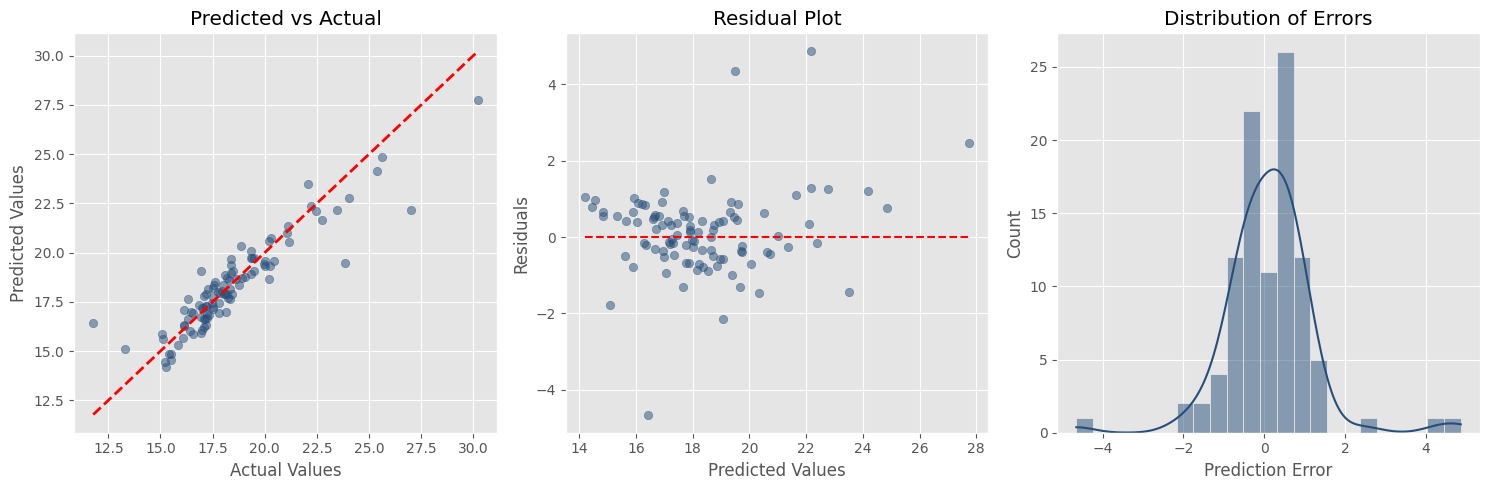

In [88]:
plot_for_analysis_model(results_L2["y_true"], results_L2["y_pred"])

Best k (PCA to 45 comps): 4 (RMSE=1.4041)
Best k (PCA to 45 comps): 4 (RMSE=1.3309)
Best k (PCA to 45 comps): 4 (RMSE=0.9878)
Best k (PCA to 45 comps): 3 (RMSE=1.4035)
Best k (PCA to 45 comps): 2 (RMSE=1.4211)
Best k (PCA to 45 comps): 4 (RMSE=1.4767)
Best k (PCA to 45 comps): 3 (RMSE=1.2507)
Best k (PCA to 45 comps): 3 (RMSE=1.3612)
Best k (PCA to 45 comps): 3 (RMSE=1.3929)
Best k (PCA to 45 comps): 4 (RMSE=1.2769)
Average MSE: 2.2182
Standard deviation of MSE: 2.9853
The RMSE: 1.4894


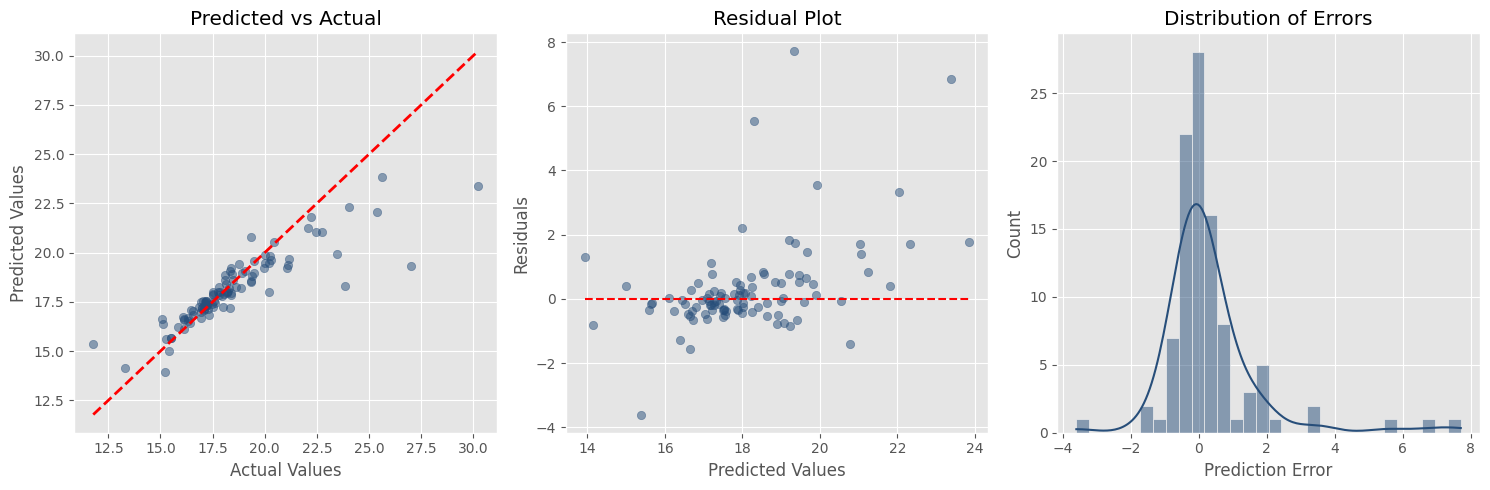

In [197]:
class KNNwithPCA:
    def __init__(self, **kwargs):
        self.k_values = kwargs.get('k_values', range(1, 10, 1))
        self.n_splits = kwargs.get('n_splits', 10)
        self.random_state = kwargs.get('random_state', 42)
        self.n_components = kwargs.get('n_components', 23) 
        self.best_k = None
        self.pca = PCAWrapper(self.n_components)
        self.X_train = None
        self.y_train = None
        self.mean = None
        self.std = None

    def fit(self, data):
        X, y = data.X, data.y
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)
        self.std[self.std == 0] = 1.0
        X = (X - self.mean) / self.std
        # PCA fit
        Z = self.pca.fit_transform(X)
        self.X_train = Z
        self.y_train = y

        # --- Cross-validate to choose k ---
        best_rmse = float('inf')
        kf = KFold(n_splits=self.n_splits, shuffle=True, random_state=self.random_state)

        for k in self.k_values:
            rmse_list = []
            for train_idx, val_idx in kf.split(Z):
                Z_tr, Z_val = Z[train_idx], Z[val_idx]
                y_tr, y_val = y[train_idx], y[val_idx]

                y_val_pred = []
                for z in Z_val:
                    dists = np.sqrt(np.sum((Z_tr - z)**2, axis=1))
                    nn_idx = np.argsort(dists)[:k]
                    y_val_pred.append(np.mean(y_tr[nn_idx]))
                y_val_pred = np.array(y_val_pred)

                rmse = np.sqrt(np.mean((y_val - y_val_pred) ** 2))
                rmse_list.append(rmse)

            avg_rmse = np.mean(rmse_list)
            if avg_rmse < best_rmse:
                best_rmse = avg_rmse
                self.best_k = k

        print(f"Best k (PCA to {self.n_components} comps): {self.best_k} (RMSE={best_rmse:.4f})")

    def predict(self, X):
        X = (X - self.mean) / self.std
        Z = self.pca.transform(X)
        y_pred = []
        for z in Z:
            dists = np.sqrt(np.sum((self.X_train - z)**2, axis=1))
            nn_idx = np.argsort(dists)[:self.best_k]
            y_pred.append(np.mean(self.y_train[nn_idx]))
        return np.array(y_pred).reshape(-1, 1)

results = evaluate_model_cv(KNNwithPCA, data_train, k=10, k_values=range(1, 10, 1), n_components=45)

plot_for_analysis_model(results["y_true"], results["y_pred"])

Best k (Poly+KNN): 4 (RMSE=1.3191)
Best k (Poly+KNN): 3 (RMSE=1.3014)
Best k (Poly+KNN): 2 (RMSE=1.0353)
Best k (Poly+KNN): 3 (RMSE=1.3043)
Best k (Poly+KNN): 1 (RMSE=1.2926)
Best k (Poly+KNN): 1 (RMSE=1.3067)
Best k (Poly+KNN): 2 (RMSE=1.2474)
Best k (Poly+KNN): 1 (RMSE=1.3281)
Best k (Poly+KNN): 2 (RMSE=1.2519)
Best k (Poly+KNN): 1 (RMSE=1.2151)
Average MSE: 1.8741
Standard deviation of MSE: 2.0776
The RMSE: 1.3690


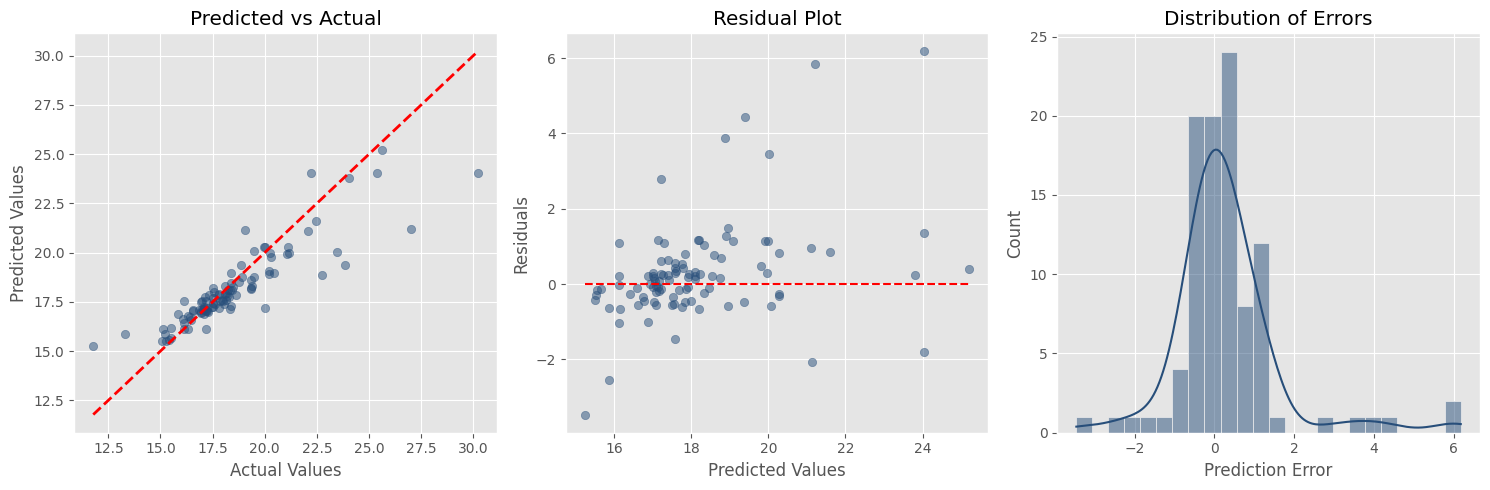

In [ ]:
class PolyKNNModel():
    def __init__(self, **kwargs):
        self.degree = kwargs.get('degree', 2)
        self.k_values = kwargs.get('k_values', range(1,10))
        self.n_splits = kwargs.get('n_splits', 10)
        self.n_components = kwargs.get('n_components', 23) 
        self.random_state = kwargs.get('random_state', 42)
        self.pca = PCAWrapper(self.n_components)
        self.best_k = None
        self.mean = None
        self.std = None
        self.X_train = None
        self.y_train = None

    def poly_expand(self, X):
        feats = [np.ones((X.shape[0],1))]
        for d in range(1, self.degree+1):
            feats.append(X**d)
        return np.hstack(feats)
    
    def poly_features(self, X):
        return np.hstack((np.ones((X.shape[0], 1)),*[X**m for m in range(1, self.degree + 1)]))

    def fit(self, data):
        X, y = data.X, data.y
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)
        self.std[self.std == 0] = 1.0
        X = (X - self.mean) / self.std
        X_poly = self.poly_features(X)

        self.X_train = X_poly
        self.y_train = y
        # --- CV to find best k ---
        best_rmse = float('inf')
        kf = KFold(n_splits=self.n_splits, shuffle=True, random_state=self.random_state)
        for k in self.k_values:
            rmse_list = []
            for train_idx, val_idx in kf.split(X_poly):
                X_tr, X_val = X_poly[train_idx], X_poly[val_idx]
                y_tr, y_val = y[train_idx], y[val_idx]
                
                y_val_pred = []
                for x in X_val:
                    dists = np.sqrt(np.sum((X_tr - x)**2, axis=1))
                    nn_idx = np.argsort(dists)[:k]
                    y_val_pred.append(np.mean(y_tr[nn_idx]))
                rmse = np.sqrt(np.mean((y_val - np.array(y_val_pred))**2))
                rmse_list.append(rmse)

            avg_rmse = np.mean(rmse_list)
            if avg_rmse < best_rmse:
                best_rmse = avg_rmse
                self.best_k = k

        print(f"Best k (Poly+KNN): {self.best_k} (RMSE={best_rmse:.4f})")

    def predict(self, X):
        X = (X - self.mean) / self.std
        X_poly = self.poly_features(X)
        y_pred = []
        for x in X_poly:
            dists = np.sqrt(np.sum((self.X_train - x)**2, axis=1))
            nn_idx = np.argsort(dists)[:self.best_k]
            y_pred.append(np.mean(self.y_train[nn_idx]))
        return np.array(y_pred).reshape(-1,1)
    
results = evaluate_model_cv(PolyKNNModel, data_train, k=10, degree=2, k_values=range(1,5), n_components=30)
plot_for_analysis_model(results["y_true"], results["y_pred"])


Best k (Poly+KNN+PCA, distance-weighted): 3 (RMSE=1.2480)
Best k (Poly+KNN+PCA, distance-weighted): 4 (RMSE=1.2311)
Best k (Poly+KNN+PCA, distance-weighted): 3 (RMSE=0.9961)
Best k (Poly+KNN+PCA, distance-weighted): 4 (RMSE=1.2559)
Best k (Poly+KNN+PCA, distance-weighted): 2 (RMSE=1.2693)
Best k (Poly+KNN+PCA, distance-weighted): 1 (RMSE=1.2683)
Best k (Poly+KNN+PCA, distance-weighted): 2 (RMSE=1.1899)
Best k (Poly+KNN+PCA, distance-weighted): 3 (RMSE=1.2633)
Best k (Poly+KNN+PCA, distance-weighted): 2 (RMSE=1.1852)
Best k (Poly+KNN+PCA, distance-weighted): 1 (RMSE=1.1727)
Average MSE: 1.5483
Standard deviation of MSE: 1.6453
The RMSE: 1.2443


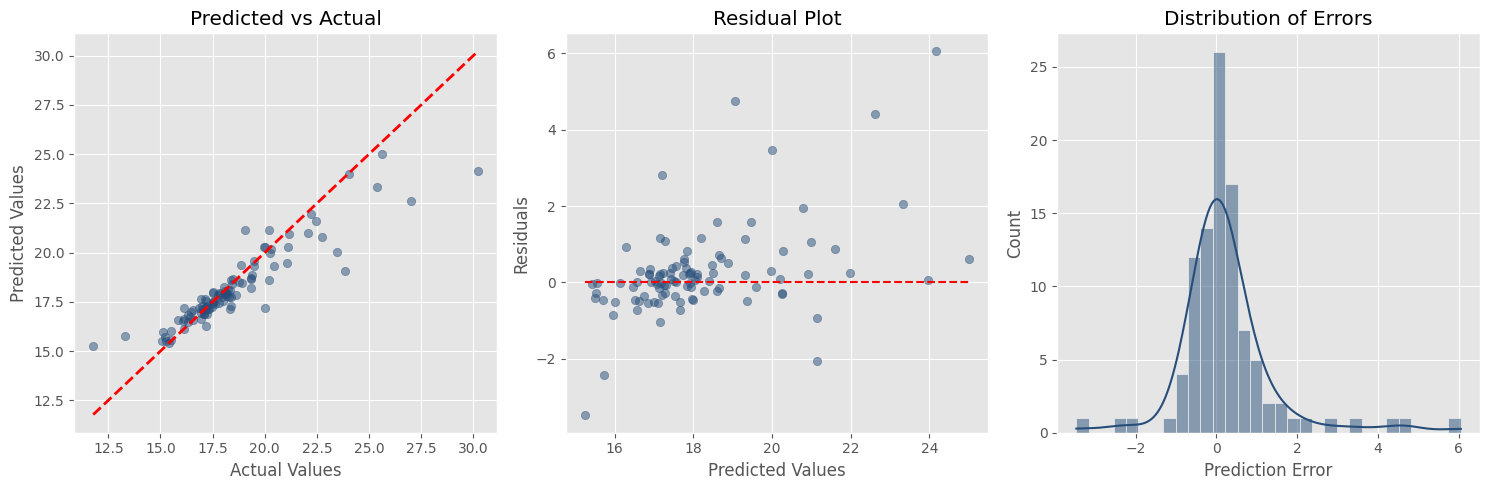

In [17]:
class PolyKNNModel_dw():
    def __init__(self, **kwargs):
        self.degree = kwargs.get('degree', 2)
        self.k_values = kwargs.get('k_values', range(1,15))
        self.n_splits = kwargs.get('n_splits', 10)
        self.n_components = kwargs.get('n_components', None)  # PCA 維度
        self.random_state = kwargs.get('random_state', 42)
        self.best_k = None
        self.mean = None
        self.std = None
        self.X_train = None
        self.y_train = None
        self.Vt = None   # PCA 投影矩陣

    def poly_features(self, X):
        return np.hstack((np.ones((X.shape[0], 1)), *[X**m for m in range(1, self.degree + 1)]))

    def _fit_pca(self, X):
        # SVD-based PCA
        U, S, Vt = np.linalg.svd(X, full_matrices=False)
        if self.n_components is not None:
            self.Vt = Vt[:self.n_components, :]
            return X @ self.Vt.T
        else:
            self.Vt = None
            return X

    def _transform_pca(self, X):
        if self.Vt is not None:
            return X @ self.Vt.T
        return X

    def fit(self, data):
        X, y = data.X, data.y
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)
        self.std[self.std == 0] = 1.0
        X = (X - self.mean) / self.std

        X_poly = self.poly_features(X)

        X_poly = self._fit_pca(X_poly)

        self.X_train = X_poly
        self.y_train = y

        # --- CV to find best k ---
        best_rmse = float('inf')
        kf = KFold(n_splits=self.n_splits, shuffle=True, random_state=self.random_state)
        for k in self.k_values:
            rmse_list = []
            for train_idx, val_idx in kf.split(X_poly):
                X_tr, X_val = X_poly[train_idx], X_poly[val_idx]
                y_tr, y_val = y[train_idx], y[val_idx]

                y_val_pred = []
                for x in X_val:
                    dists = np.sqrt(np.sum((X_tr - x)**2, axis=1))
                    nn_idx = np.argsort(dists)[:k]
                    # distance weighting
                    weights = 1 / (dists[nn_idx] + 1e-8)
                    weights /= np.sum(weights)
                    y_val_pred.append(np.sum(weights * y_tr[nn_idx]))
                rmse = np.sqrt(np.mean((y_val - np.array(y_val_pred))**2))
                rmse_list.append(rmse)

            avg_rmse = np.mean(rmse_list)
            if avg_rmse < best_rmse:
                best_rmse = avg_rmse
                self.best_k = k

        print(f"Best k (Poly+KNN+PCA, distance-weighted): {self.best_k} (RMSE={best_rmse:.4f})")

    def predict(self, X):
        
        X = (X - self.mean) / self.std
        X_poly = self.poly_features(X)
        X_poly = self._transform_pca(X_poly)

        y_pred = []
        for x in X_poly:
            dists = np.sqrt(np.sum((self.X_train - x)**2, axis=1))
            nn_idx = np.argsort(dists)[:self.best_k]
            # distance weighting
            weights = 1 / (dists[nn_idx] + 1e-8)
            weights /= np.sum(weights)
            y_pred.append(np.sum(weights * self.y_train[nn_idx]))
        return np.array(y_pred).reshape(-1,1)
results = evaluate_model_cv(PolyKNNModel_dw, data_train, k=10, degree=2, k_values=range(1,10), n_components=15)
plot_for_analysis_model(results["y_true"], results["y_pred"])

- Poly+KNN (uniform, no PCA): RMSE ≈ 1.37
- Poly+KNN+PCA (distance-weighted): RMSE ≈ 1.24
Building on the Polynomial model, we combined it with KNN to improve performance, and further introduced PCA with distance-weighted KNN. This integration successfully reduced the RMSE from about 1.37 to 1.24.
Additionally, a ensemble may help reduce systematic prediction errors observed around y-values 25–30.

Best ridge_lambda: 100 (RMSE=1.5956)
Best ridge_lambda: 100 (RMSE=1.6259)
Best ridge_lambda: 100 (RMSE=1.4253)
Best ridge_lambda: 100 (RMSE=1.6391)
Best ridge_lambda: 100 (RMSE=1.6795)
Best ridge_lambda: 10 (RMSE=1.5331)
Best ridge_lambda: 100 (RMSE=1.4930)
Best ridge_lambda: 100 (RMSE=1.5259)
Best ridge_lambda: 100 (RMSE=1.5966)
Best ridge_lambda: 100 (RMSE=1.4893)
Average MSE: 2.7640
Standard deviation of MSE: 1.9648
The RMSE: 1.6625


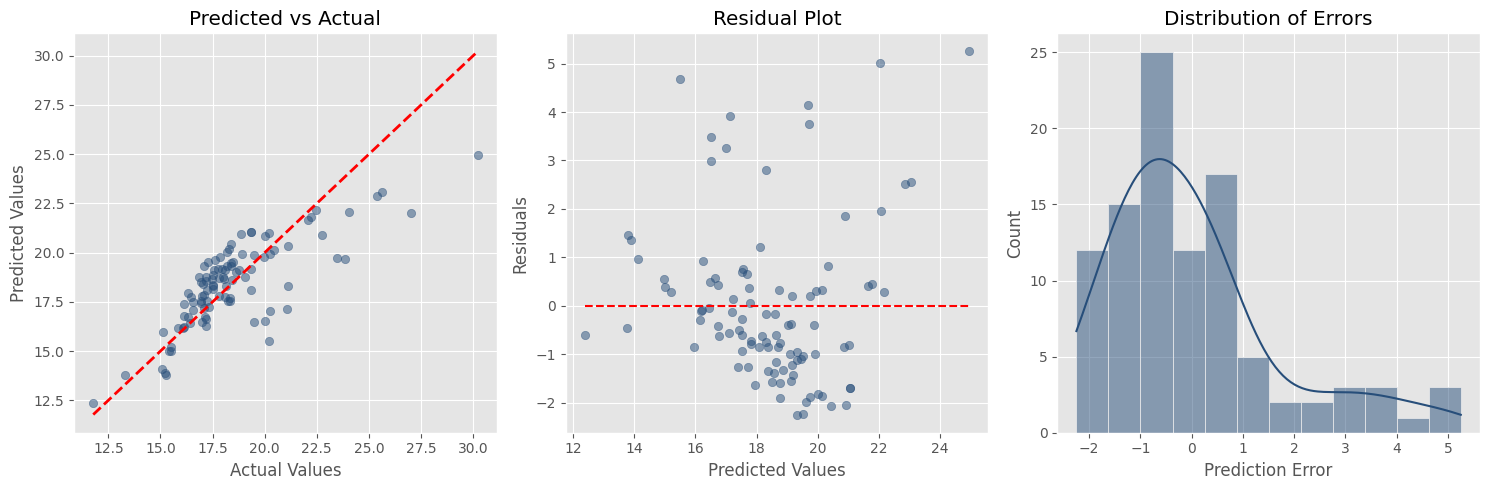

In [210]:
class PCA_Ridge_Model():
    """ 
    PCA + Ridge regression with automatic ridge_lambda selection via KFold CV.
    """
    def __init__(self, **kwargs):
        self.n_components = kwargs.get('n_components', 23)
        self.ridge_values = kwargs.get('ridge_values', [0.01, 0.1, 0.5, 1.0, 10.0, 100.0])
        self.n_splits = kwargs.get('n_splits', 10)
        self.random_state = kwargs.get('random_state', 42)
        self.best_lambda = None
        self.mean_X = None
        self.std_X = None
        self.mean_y = None
        self.Vt = None
        self.coef_ = None

    def fit(self, data):
        X, y = data.X, data.y
        n, p = X.shape

        # Standardize X
        self.mean_X = np.mean(X, axis=0)
        self.std_X = np.std(X, axis=0)
        X_scaled = (X - self.mean_X) / self.std_X

        # Center y
        self.mean_y = np.mean(y)
        y_centered = y - self.mean_y

        # PCA via SVD
        U, S, Vt = np.linalg.svd(X_scaled, full_matrices=False)
        self.Vt = Vt[:self.n_components, :]  

        # Project onto top PCs
        Z_full = X_scaled @ self.Vt.T

        # --- KFold CV to choose best ridge_lambda ---
        best_rmse = float('inf')
        kf = KFold(n_splits=self.n_splits, shuffle=True, random_state=self.random_state)

        for lam in self.ridge_values:
            rmse_list = []
            for train_idx, val_idx in kf.split(Z_full):
                Z_train, Z_val = Z_full[train_idx], Z_full[val_idx]
                y_train, y_val = y_centered[train_idx], y_centered[val_idx]

                # Ridge regression
                beta = np.linalg.inv(Z_train.T @ Z_train + lam * np.eye(self.n_components)) @ (Z_train.T @ y_train)
                y_pred = Z_val @ beta
                rmse = np.sqrt(np.mean((y_pred - y_val) ** 2))
                rmse_list.append(rmse)

            avg_rmse = np.mean(rmse_list)
            if avg_rmse < best_rmse:
                best_rmse = avg_rmse
                self.best_lambda = lam
        print(f"Best ridge_lambda: {self.best_lambda} (RMSE={best_rmse:.4f})")

        # --- Fit final model on full data with best lambda ---
        self.coef_ = np.linalg.inv(Z_full.T @ Z_full + self.best_lambda * np.eye(self.n_components)) @ (Z_full.T @ y_centered)

    def predict(self, X):
        X_scaled = (X - self.mean_X) / self.std_X
        Z = X_scaled @ self.Vt.T
        y_pred = Z @ self.coef_ + self.mean_y

        return y_pred.reshape(-1, 1)
    
results = evaluate_model_cv(PCA_Ridge_Model, data_train, k=10, n_components=23, ridge_values=[0.01, 0.1, 1, 10, 100])

plot_for_analysis_model(results["y_true"], results["y_pred"])

The PCA + Ridge model achieved an average RMSE of  across 10-fold cross-validation. The model consistently selected larger ridge penalties ($\lambda = 100$ in most folds), suggesting that strong regularization was required to stabilize the coefficients. This indicates the data may contain multicollinearity or noise that PCA alone did not fully address. While the performance is reasonable, it is not the best among the models we tested.

Average MSE: 2.1028
Standard deviation of MSE: 2.7145
The RMSE: 1.4501


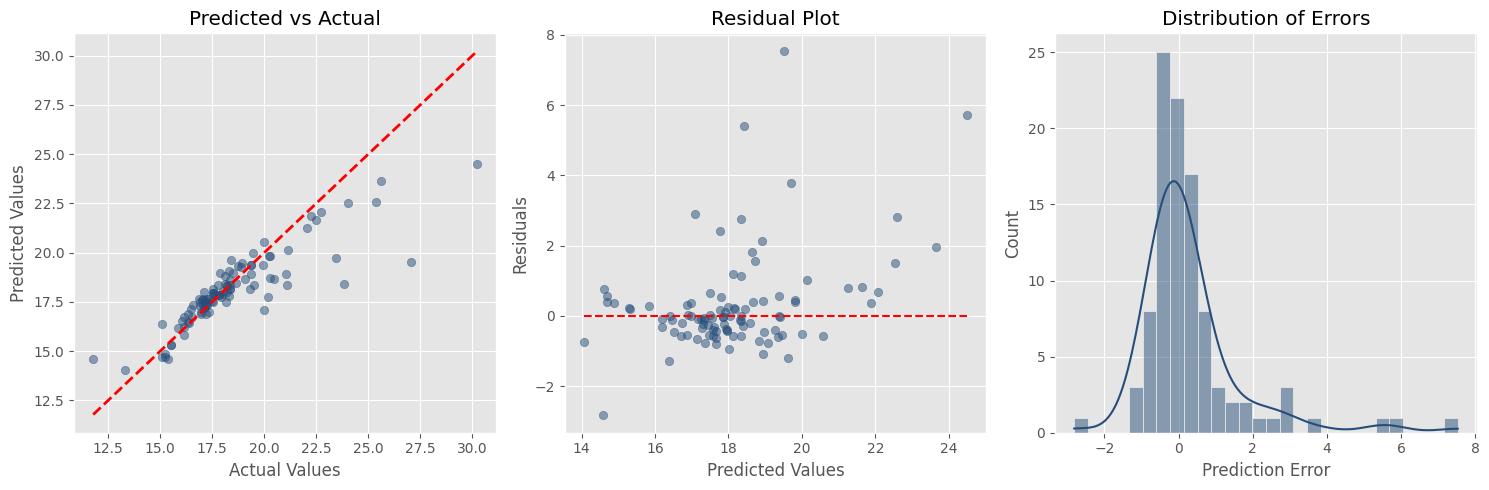

In [ ]:
class PCA_Ridge_KNN():
    def __init__(self, **model_kwargs):
        self.n_components = model_kwargs.get('n_components', 23)
        self.ridge_values = model_kwargs.get('ridge_values', [0.1, 1, 10])
        self.k_values = model_kwargs.get('k_values', range(1, 10))
        self.alpha_values = model_kwargs.get('alpha_values', [0.2, 0.5, 0.8])
        self.n_splits = model_kwargs.get('n_splits', 10)
        self.random_state = model_kwargs.get('random_state', 42)

        self.best_params = None
        self.mean_X = None
        self.std_X = None
        self.mean_y = None
        self.Vt = None
        self.ridge_coef_ = None
        self.knn_X_train = None
        self.knn_y_train = None

    def fit(self, data):
        X, y = data.X, data.y
        self.mean_X = np.mean(X, axis=0)
        self.std_X = np.std(X, axis=0)
        self.std_X[self.std_X == 0] = 1.0
        X_scaled = (X - self.mean_X) / self.std_X

        self.mean_y = np.mean(y)
        y_centered = y - self.mean_y

        # PCA
        U, S, Vt = np.linalg.svd(X_scaled, full_matrices=False)
        self.Vt = Vt[:self.n_components, :]
        Z_full = X_scaled @ self.Vt.T 
        # --- Cross-validation to pick best (ridge_lambda, k, alpha) ---
        best_rmse = float('inf')
        kf = KFold(n_splits=self.n_splits, shuffle=True, random_state=self.random_state)

        for lam in self.ridge_values:
            for k in self.k_values:
                for alpha in self.alpha_values:
                    fold_rmse = []
                    for train_idx, val_idx in kf.split(Z_full):
                        Z_tr, Z_val = Z_full[train_idx], Z_full[val_idx]
                        y_tr, y_val = y_centered[train_idx], y_centered[val_idx]

                        beta = np.linalg.pinv(Z_tr.T @ Z_tr + lam*np.eye(self.n_components)) @ (Z_tr.T @ y_tr)
                        y_ridge = Z_val @ beta
                        X_tr_knn, X_val_knn = X_scaled[train_idx], X_scaled[val_idx]
                        dists = np.sqrt(np.sum((X_val_knn[:, None, :] - X_tr_knn[None, :, :])**2, axis=2))
                        nn_idx = np.argsort(dists, axis=1)[:, :k]
                        y_knn = np.mean(y_tr[nn_idx], axis=1)

                        y_pred = alpha*y_knn + (1-alpha)*y_ridge
                        fold_rmse.append(np.sqrt(np.mean((y_pred - y_val)**2)))

                    avg_rmse = np.mean(fold_rmse)
                    if avg_rmse < best_rmse:
                        best_rmse = avg_rmse
                        self.best_params = (lam, k, alpha)

        lam, k, alpha = self.best_params
        self.ridge_coef_ = np.linalg.pinv(Z_full.T @ Z_full + lam*np.eye(self.n_components)) @ (Z_full.T @ y_centered)
        self.knn_X_train = X_scaled
        self.knn_y_train = y_centered
        self.best_k = k
        self.alpha = alpha

    def predict(self, X):
        X_scaled = (X - self.mean_X) / self.std_X
        Z = X_scaled @ self.Vt.T
        y_ridge = Z @ self.ridge_coef_
        # KNN
        dists = np.sqrt(np.sum((X_scaled[:, None, :] - self.knn_X_train[None, :, :])**2, axis=2))
        nn_idx = np.argsort(dists, axis=1)[:, :self.best_k]
        y_knn = np.mean(self.knn_y_train[nn_idx], axis=1)

        # Hybrid prediction + mean
        y_pred = self.alpha * y_knn + (1 - self.alpha) * y_ridge + self.mean_y
        return y_pred.reshape(-1, 1)

results = evaluate_model_cv(PCA_Ridge_KNN, data_train, k=10, n_components=45, 
                            ridge_values=[0.1, 1, 10], k_values=range(1, 5), alpha_values=np.linspace(0, 1,11))
plot_for_analysis_model(results["y_true"], results["y_pred"])



This hybrid model combines PCA-reduced Ridge regression with KNN, it strikes a balance between bias and variance. Ridge helps stabilize the model and control overfitting in high-dimensional space, while KNN is able to capture nonlinear local patterns. The averaging weight α adjusts the contribution of each component. The results (RMSE = 1.45) show that this hybrid approach outperforms either Ridge or KNN alone, confirming that the ensemble mitigates the limitations of individual models. However, the relatively large standard deviation of the MSE suggests that performance is not uniform across all regions of the data. To address this, we will further explore a more flexible framework: **Hybrid_PCA_RidgeOrLasso_KNN_Model**

KNN best k = 4, RMSE = 1.4041
KNN best k = 4, RMSE = 1.3309
KNN best k = 4, RMSE = 0.9878
KNN best k = 3, RMSE = 1.4035
KNN best k = 2, RMSE = 1.4211
KNN best k = 4, RMSE = 1.4767
KNN best k = 3, RMSE = 1.2507
KNN best k = 3, RMSE = 1.3612
KNN best k = 3, RMSE = 1.3929
KNN best k = 4, RMSE = 1.2769
Average MSE: 2.2182
Standard deviation of MSE: 2.9853
The RMSE: 1.4894


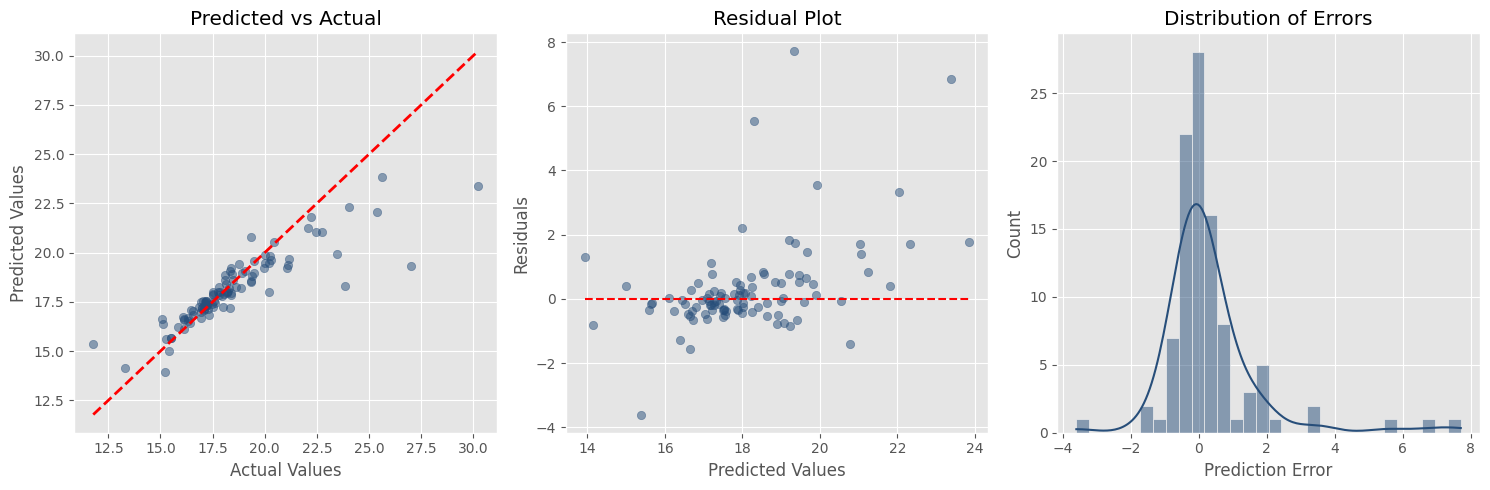

In [258]:
class KNNRegressor:
    def __init__(self, **kwargs):
        self.k = kwargs.get('k', 5)
        self.n_components = kwargs.get('n_components', 23)  # for PCA
        self.distance_metric = kwargs.get('distance_metric', "euclidean")
        self.weighting = kwargs.get('weighting', "uniform")
        self.scaler = kwargs.get('scaler', "zscore")
        self.n_splits = kwargs.get('n_splits', 10)
        self.random_state = kwargs.get('random_state', 42)
        self.k_values = kwargs.get('k_values', range(1, 5))
        # training data
        self.X = None
        self.y = None
        self.pca = None
        self.best_k = None
        # robust/zscore
        self.median_X = None
        self.iqr_X = None
        self.mean_X = None
        self.std_X = None

    def _scale_fit(self, X):
        if self.scaler == "zscore":
            self.mean_X = np.mean(X, axis=0)
            self.std_X = np.std(X, axis=0)
            self.std_X[self.std_X == 0] = 1.0
        elif self.scaler == "robust":
            self.median_X = np.median(X, axis=0)
            q1 = np.percentile(X, 25, axis=0)
            q3 = np.percentile(X, 75, axis=0)
            self.iqr_X = q3 - q1
            self.iqr_X[self.iqr_X == 0] = 1.0

    def _scale_transform(self, X):
        if self.scaler == "zscore":
            return (X - self.mean_X) / self.std_X
        elif self.scaler == "robust":
            return (X - self.median_X) / self.iqr_X
        else:
            return X

    def _compute_distances(self, X_val, X_tr):
        if self.distance_metric == "euclidean":
            return np.linalg.norm(X_val[:, None, :] - X_tr[None, :, :], axis=2)
        elif self.distance_metric == "manhattan":
            return np.sum(np.abs(X_val[:, None, :] - X_tr[None, :, :]), axis=2)

    def fit(self, data):
        X, y = data.X, data.y
        self._scale_fit(X)
        X = self._scale_transform(X)
        if self.n_components is not None:
            self.pca = PCAWrapper(self.n_components)
            X = self.pca.fit_transform(X)

        self.X, self.y = X, y
        best_rmse = float("inf")
        kf = KFold(n_splits=self.n_splits, shuffle=True, random_state=self.random_state)
        for k_candidate in self.k_values:
            fold_rmse = []
            for train_idx, val_idx in kf.split(X):
                X_tr, X_val = X[train_idx], X[val_idx]
                y_tr, y_val = y[train_idx], y[val_idx]
                dists = self._compute_distances(X_val, X_tr)
                nn_idx = np.argsort(dists, axis=1)[:, :k_candidate]
                if self.weighting == "uniform":
                    y_pred = np.mean(y_tr[nn_idx], axis=1)
                elif self.weighting == "distance":
                    weights = 1 / (dists[np.arange(len(dists))[:, None], nn_idx] + 1e-8)
                    weights /= np.sum(weights, axis=1, keepdims=True)
                    y_pred = np.sum(weights * y_tr[nn_idx], axis=1)
                fold_rmse.append(np.sqrt(np.mean((y_val - y_pred)**2)))
            avg_rmse = np.mean(fold_rmse)
            if avg_rmse < best_rmse:
                best_rmse = avg_rmse
                self.best_k = k_candidate
        self.k = self.best_k
        print(f"KNN best k = {self.k}, RMSE = {best_rmse:.4f}")

    def predict(self, X_new):
        X_new = self._scale_transform(X_new)
        if self.pca is not None:
            X_new = self.pca.transform(X_new)
        dists = self._compute_distances(X_new, self.X)
        nn_idx = np.argsort(dists, axis=1)[:, :self.k]
        if self.weighting == "uniform":
            return np.mean(self.y[nn_idx], axis=1)   # (n_samples,)
        elif self.weighting == "distance":
            weights = 1 / (dists[np.arange(len(dists))[:, None], nn_idx] + 1e-8)
            weights /= np.sum(weights, axis=1, keepdims=True)
            return np.sum(weights * self.y[nn_idx], axis=1)

results = evaluate_model_cv(KNNRegressor, data_train, k=10, k_values=range(1,10), n_components=45, distance_metric="euclidean", weighting="uniform", scaler="zscore")
plot_for_analysis_model(results["y_true"], results["y_pred"])


In our KNNRegressor, we tested different combinations of distance metrics, weighting schemes, and scaling methods. The best performance was achieved using distance_metric="euclidean", weighting="uniform", and scaler="zscore", resulting in an RMSE of 1.4894. While this is an improvement over some baseline models, the error is still relatively high, indicating that there is room for further optimization.

In [250]:
def soft_threshold(rho, lam):
    if rho < -lam:
        return rho + lam
    elif rho > lam:
        return rho - lam
    else:
        return 0

def fit_linear_model(Z, y, lam, method="ridge", num_iters=100):
    """Fit ridge or lasso (coordinate descent)."""
    if method == "ridge":
        beta = np.linalg.pinv(Z.T @ Z + lam * np.eye(Z.shape[1])) @ (Z.T @ y)
    elif method == "lasso":
        beta = np.zeros(Z.shape[1])
        for _ in range(num_iters):
            for j in range(Z.shape[1]):
                residual = y - (Z @ beta) + beta[j] * Z[:, j]
                rho = Z[:, j].T @ residual
                beta[j] = soft_threshold(rho / (Z[:, j] @ Z[:, j]), lam)
    else:
        raise ValueError("Unsupported method: choose 'ridge' or 'lasso'")
    return beta

class Hybrid_PCA_RidgeOrLasso_KNN_Model:
    """Hybrid Linear (ridge or lasso) + KNN regression using PCA-reduced features."""
    def __init__(self, **kwargs):
        self.n_components = kwargs.get('n_components', 10)
        self.linear_values = kwargs.get('linear_values', [10**i for i in range(-3, 4)])  # lambdas
        self.k_values = kwargs.get('k_values', range(1, 15))
        self.alpha_values = kwargs.get('alpha_values', np.linspace(0, 1, 11))
        self.n_splits = kwargs.get('n_splits', 10)
        self.random_state = kwargs.get('random_state', 42)
        self.linear_method = kwargs.get('linear_method', 'ridge')  # 'ridge' or 'lasso'

        self.mean_X = None
        self.std_X = None
        self.mean_y = None
        self.Vt = None
        self.linear_coef_ = None
        self.knn_model = None
        self.best_params = None
        self.alpha = None

    def fit(self, data):
        X, y = data.X, data.y

        # Standardize X
        self.mean_X = np.mean(X, axis=0)
        self.std_X = np.std(X, axis=0)
        self.std_X[self.std_X == 0] = 1.0
        X_scaled = (X - self.mean_X) / self.std_X

        # Center y
        self.mean_y = np.mean(y)
        y_centered = y - self.mean_y

        # PCA
        U, S, Vt = np.linalg.svd(X_scaled, full_matrices=False)
        self.Vt = Vt[:self.n_components, :]
        Z_full = X_scaled @ self.Vt.T

        # CV to select best lambda, k, alpha
        best_rmse = float('inf')
        kf = KFold(n_splits=self.n_splits, shuffle=True, random_state=self.random_state)
        for lam in self.linear_values:
            for k in self.k_values:
                for alpha in self.alpha_values:
                    fold_rmse = []
                    for train_idx, val_idx in kf.split(Z_full):
                        Z_tr, Z_val = Z_full[train_idx], Z_full[val_idx]
                        y_tr, y_val = y_centered[train_idx], y_centered[val_idx]

                        # Linear model (ridge or lasso)
                        beta = fit_linear_model(Z_tr, y_tr, lam, method=self.linear_method)
                        y_linear = Z_val @ beta

                        # KNN (manual)
                        X_tr_knn, X_val_knn = X_scaled[train_idx], X_scaled[val_idx]
                        dists = np.linalg.norm(X_val_knn[:, None, :] - X_tr_knn[None, :, :], axis=2)
                        nn_idx = np.argsort(dists, axis=1)[:, :k]
                        y_knn = np.mean(y_tr[nn_idx], axis=1)
                        # knn = KNNRegressor(
                        #     k=k,
                        #     n_components=self.n_components,
                        #     scaler="zscore",
                        #     distance_metric="euclidean",
                        #     weighting="uniform",
                        #     n_splits=self.n_splits,
                        #     random_state=self.random_state
                        # )
                        # knn.fit(DataWrapper(Z_tr, y_tr))  # assuming your data object is in same format
                        # y_knn = knn.predict(Z_val)
 

                        # Hybrid
                        y_pred = alpha * y_knn + (1 - alpha) * y_linear
                        fold_rmse.append(np.sqrt(np.mean((y_pred - y_val)**2)))

                    avg_rmse = np.mean(fold_rmse)
                    if avg_rmse < best_rmse:
                        best_rmse = avg_rmse
                        self.best_params = (lam, k, alpha)

        lam, k, alpha = self.best_params
        print(f"Best params: method={self.linear_method}, lam={lam}, k={k}, alpha={alpha}, RMSE={best_rmse:.4f}")

        # Fit final linear model
        self.linear_coef_ = fit_linear_model(Z_full, y_centered, lam, method=self.linear_method)

        # Fit final KNN
        self.knn_model = lambda X_scaled_new: np.mean(
            y_centered[np.argsort(np.linalg.norm(X_scaled_new[:, None, :] - X_scaled[None, :, :], axis=2), axis=1)[:, :k]],
            axis=1
        )
        self.alpha = alpha

    def predict(self, X_new):
        X_scaled = (X_new - self.mean_X) / self.std_X
        Z = X_scaled @ self.Vt.T

        # Linear prediction
        y_linear = Z @ self.linear_coef_

        # KNN prediction
        y_knn = self.knn_model(X_scaled)

        # Hybrid prediction
        y_pred = self.alpha * y_knn + (1 - self.alpha) * y_linear + self.mean_y
        return y_pred.reshape(-1, 1)

Best params: method=ridge, lam=10, k=2, alpha=0.7000000000000001, RMSE=1.3277
Best params: method=ridge, lam=100, k=2, alpha=0.7000000000000001, RMSE=1.3106
Best params: method=ridge, lam=0.001, k=4, alpha=0.9, RMSE=0.9712
Best params: method=ridge, lam=10, k=3, alpha=0.8, RMSE=1.3704
Best params: method=ridge, lam=100, k=2, alpha=0.8, RMSE=1.3845
Best params: method=ridge, lam=10, k=1, alpha=0.6000000000000001, RMSE=1.2783
Best params: method=ridge, lam=10, k=2, alpha=0.7000000000000001, RMSE=1.2055
Best params: method=ridge, lam=10, k=3, alpha=0.7000000000000001, RMSE=1.2823
Best params: method=ridge, lam=10, k=3, alpha=0.8, RMSE=1.3457
Best params: method=ridge, lam=10, k=4, alpha=0.7000000000000001, RMSE=1.2557
Average MSE: 2.0858
Standard deviation of MSE: 2.6803
The RMSE: 1.4442


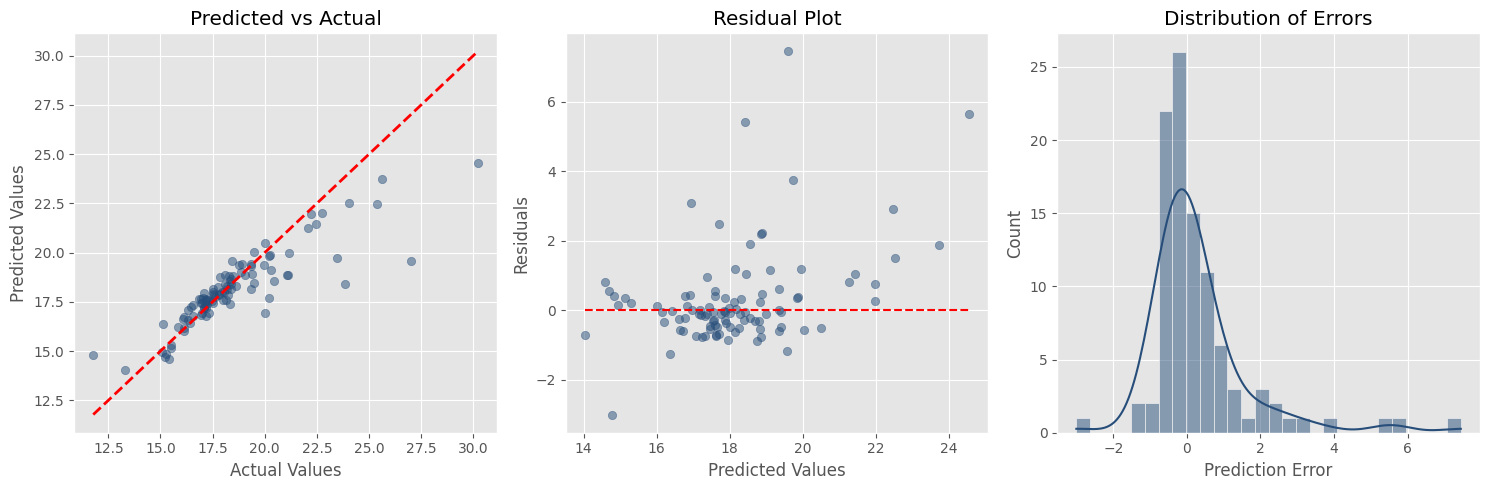

In [256]:
results = evaluate_model_cv(Hybrid_PCA_RidgeOrLasso_KNN_Model, data_train,
    n_components=23,
    ridge_values=[10**i for i in range(-3, 4)],
    k_values=range(1, 5),
    linear_method="ridge")
plot_for_analysis_model(results["y_true"], results["y_pred"])

When we incorporated the best KNNRegressor configuration into the Hybrid_PCA_RidgeOrLasso_KNN_Model, the model achieved an RMSE of 1.4442. This represents a slight improvement over the individual KNN model (RMSE 1.4894) and the PCA + Ridge model, but the gain is modest. The hybrid approach confirms that combining linear (ridge) and non-linear (KNN) components can improve predictive performance, although the improvement is limited

Best params: method=ridge, lam=10, k=2, alpha=0.7000000000000001, RMSE=1.3209
Best params: method=ridge, lam=10, k=2, alpha=0.8, RMSE=1.3095
Best params: method=ridge, lam=1, k=4, alpha=0.9, RMSE=0.9766
Best params: method=ridge, lam=100, k=3, alpha=0.8, RMSE=1.3721
Best params: method=ridge, lam=10, k=2, alpha=0.8, RMSE=1.3797
Best params: method=ridge, lam=10, k=1, alpha=0.6000000000000001, RMSE=1.2693
Best params: method=ridge, lam=10, k=2, alpha=0.7000000000000001, RMSE=1.2025
Best params: method=ridge, lam=10, k=3, alpha=0.7000000000000001, RMSE=1.2725
Best params: method=ridge, lam=10, k=3, alpha=0.7000000000000001, RMSE=1.3334
Best params: method=ridge, lam=1, k=4, alpha=0.7000000000000001, RMSE=1.2286
Average MSE: 2.1028
Standard deviation of MSE: 2.7145
The RMSE: 1.4501


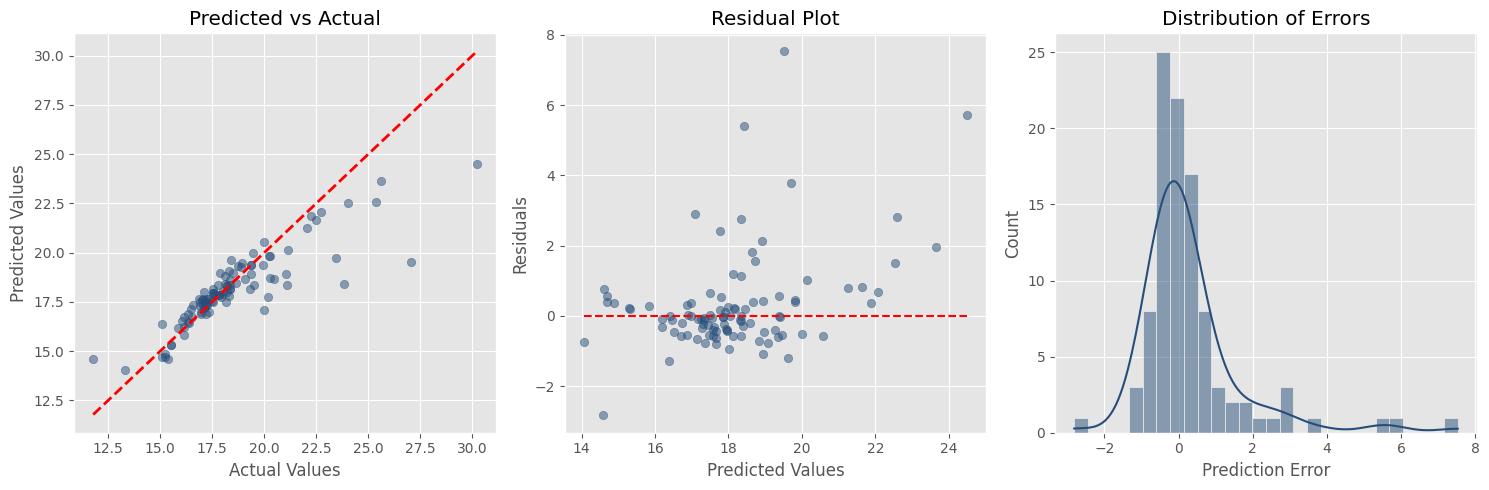

In [251]:
results = evaluate_model_cv(Hybrid_PCA_RidgeOrLasso_KNN_Model, data_train,
    n_components=45,
    ridge_values=[10**i for i in range(-3, 4)],
    k_values=range(1, 5),
    linear_method="ridge")
plot_for_analysis_model(results["y_true"], results["y_pred"])

when we chage to Lasso method the RMSE didn't improve.

Best params: method=lasso, lam=0.001, k=2, alpha=0.8, RMSE=1.3357
Best params: method=lasso, lam=0.001, k=4, alpha=0.9, RMSE=1.3183
Best params: method=lasso, lam=0.001, k=4, alpha=0.9, RMSE=0.9808
Best params: method=lasso, lam=0.001, k=3, alpha=0.9, RMSE=1.3844
Best params: method=lasso, lam=0.001, k=2, alpha=0.9, RMSE=1.3898
Best params: method=lasso, lam=0.001, k=1, alpha=0.8, RMSE=1.3454
Best params: method=lasso, lam=0.001, k=2, alpha=0.8, RMSE=1.2245
Best params: method=lasso, lam=0.001, k=3, alpha=0.8, RMSE=1.2853
Best params: method=lasso, lam=0.001, k=3, alpha=0.9, RMSE=1.3685
Best params: method=lasso, lam=0.001, k=4, alpha=0.8, RMSE=1.2311
Average MSE: 2.0429
Standard deviation of MSE: 2.7517
The RMSE: 1.4293


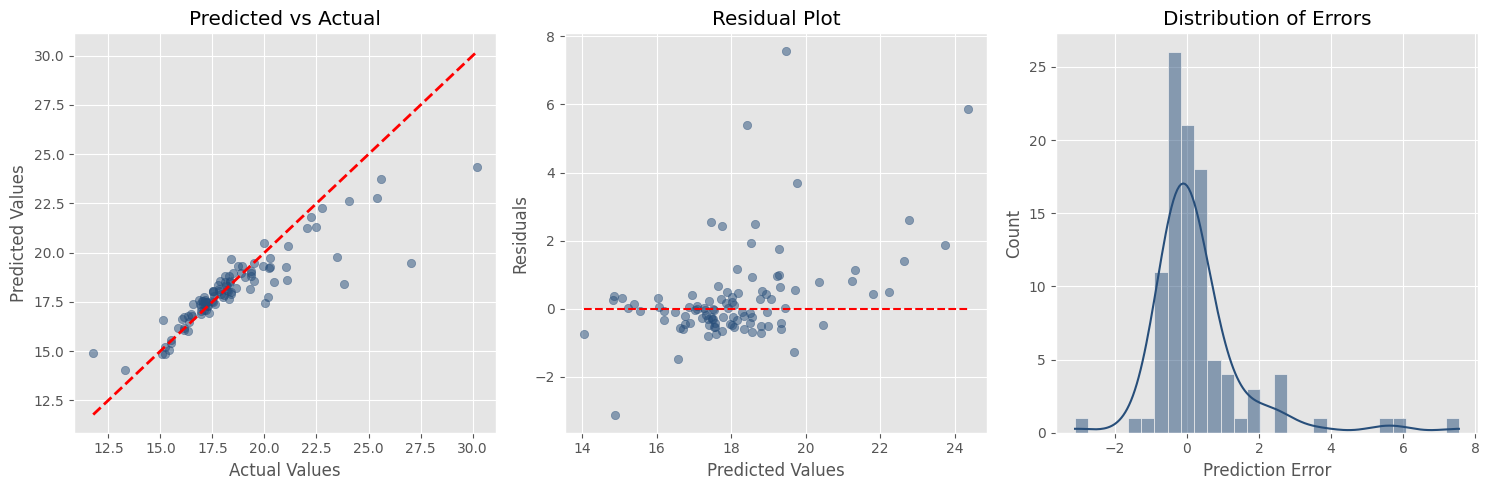

In [ ]:
results = evaluate_model_cv (Hybrid_PCA_RidgeOrLasso_KNN_Model, data_train,
    n_components=45,
    ridge_values=[10**i for i in range(-3, 4)],
    k_values=range(1, 5),
    linear_method="lasso"  # or "ridge"
)
plot_for_analysis_model(results["y_true"], results["y_pred"])

Average MSE: 330.8261
Standard deviation of MSE: 52.1610
The RMSE: 18.1886
Average MSE: 17.7884
Standard deviation of MSE: 27.9135
The RMSE: 4.2176
Average MSE: 2.1839
Standard deviation of MSE: 3.3451
The RMSE: 1.4778
Average MSE: 2.0877
Standard deviation of MSE: 3.3011
The RMSE: 1.4449
Average MSE: 2.2469
Standard deviation of MSE: 3.3061
The RMSE: 1.4990
Average MSE: 2.5868
Standard deviation of MSE: 3.4124
The RMSE: 1.6084
Average MSE: 3.0146
Standard deviation of MSE: 3.5861
The RMSE: 1.7363
Average MSE: 3.4631
Standard deviation of MSE: 3.7971
The RMSE: 1.8609
Average MSE: 3.8949
Standard deviation of MSE: 4.0224
The RMSE: 1.9735
Average MSE: 4.2933
Standard deviation of MSE: 4.2434
The RMSE: 2.0720
Average MSE: 4.6527
Standard deviation of MSE: 4.4478
The RMSE: 2.1570
Average MSE: 4.9722
Standard deviation of MSE: 4.6293
The RMSE: 2.2298
Average MSE: 5.2540
Standard deviation of MSE: 4.7858
The RMSE: 2.2922
Average MSE: 5.5015
Standard deviation of MSE: 4.9184
The RMSE: 2.3455


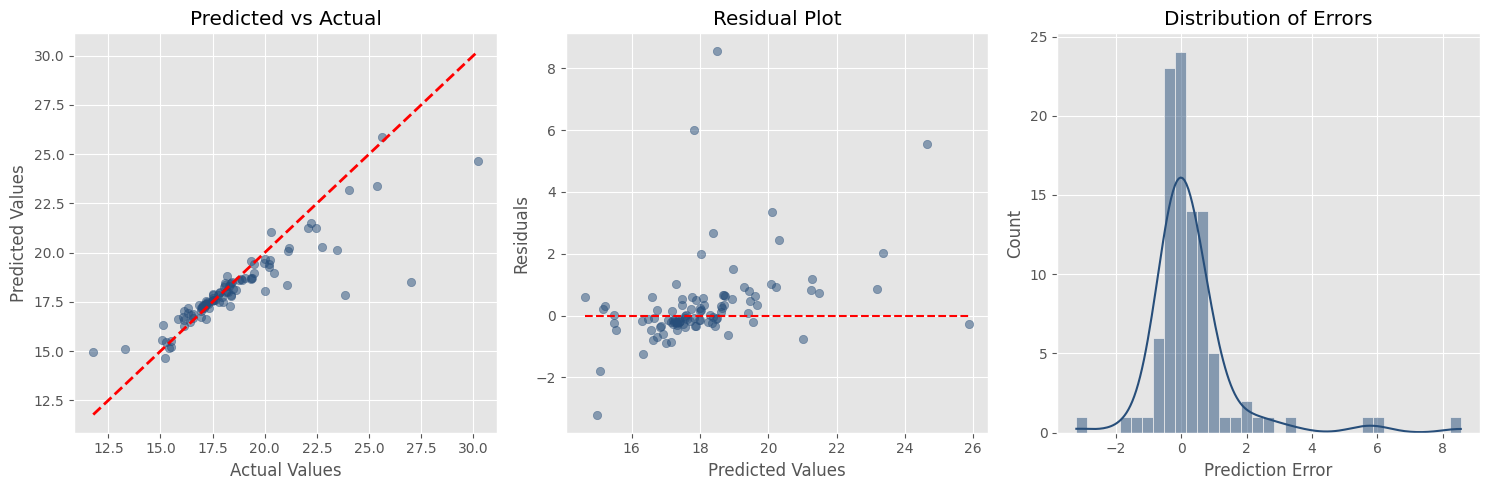

In [143]:
class KernelRegressor:
    def __init__(self, **kwargs):
        self.bw = kwargs.get('bw', 0.1)   # bandwidth
        self.X = None
        self.y = None

    def fit(self, data):
        self.X, self.y = data.X, data.y

    def predict(self, X_new):
        X_new = np.atleast_2d(X_new)  
        X_train = np.atleast_2d(self.X)

        dists = np.linalg.norm(X_new[:, None, :] - X_train[None, :, :], axis=2)

        Kh = np.exp(-0.5 * (dists / self.bw) ** 2) / (self.bw * np.sqrt(2 * np.pi))

        weights = Kh / (np.sum(Kh, axis=1, keepdims=True) + 1e-12)

        y_pred = weights @ self.y
        return y_pred.reshape(-1, 1)

bw_values = np.linspace(0.05, 2.0, 20)
results = []
for bw in bw_values:
    res = evaluate_model_cv(KernelRegressor, data_train, k=10, bw=bw)
    results.append((bw, res["rmse"]))
best_bw, best_rmse = min(results, key=lambda x: x[1])
print("Best bw:", best_bw, "RMSE:", best_rmse)

results = evaluate_model_cv(KernelRegressor, data_train, k=10, bw=best_bw)
plot_for_analysis_model(results["y_true"], results["y_pred"])


Kernel regression was also evaluated by tuning the bandwidth parameter. However, it showed weaker performance (RMSE 1.44) and high variability across folds. This suggests that kernel methods may not scale well in this setting, likely due to the higher-dimensional feature space and sensitivity to bandwidth choice. Consequently, we did not pursue kernel regression further for the final model.

Average MSE: 4.1980
Standard deviation of MSE: 1.8096
The RMSE: 2.0489


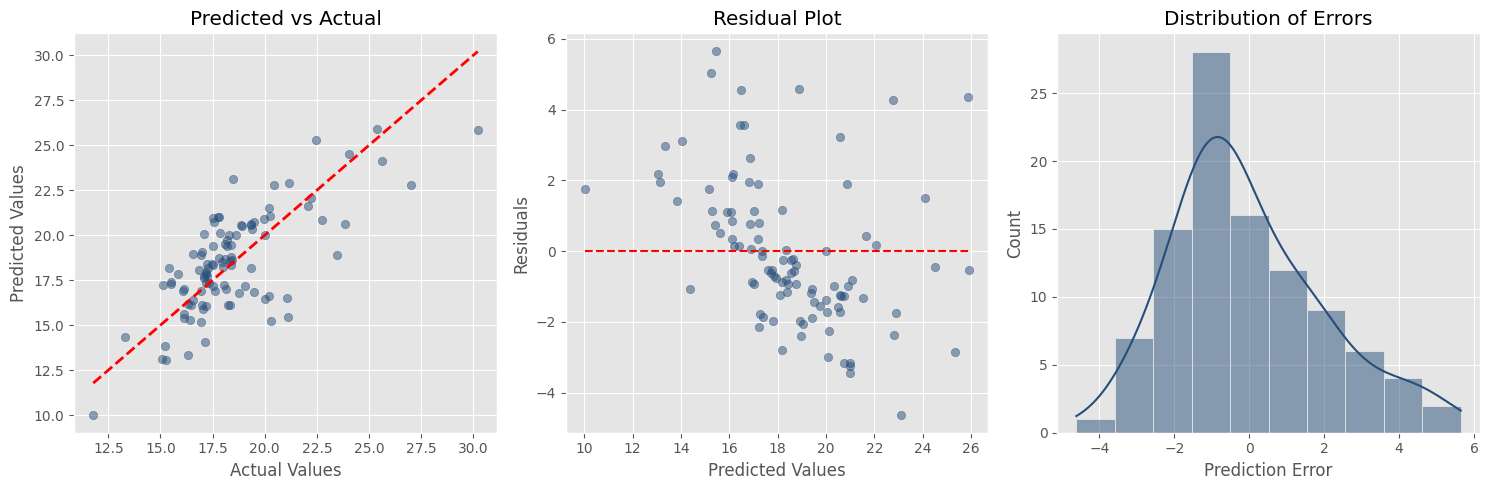

In [ ]:
class SGDRegressor:
    def __init__(self, lr=0.1, epochs=1000, verbose=False):
        self.lr = lr
        self.epochs = epochs
        self.verbose = verbose
        self.weights = None
        self.bias = None
        self.mean_ = None
        self.std_ = None
        self.loss_history = []

    def _standardize(self, X):
        self.mean_ = np.mean(X, axis=0)
        self.std_ = np.std(X, axis=0)
        self.std_[self.std_ == 0] = 1.0
        return (X - self.mean_) / self.std_

    def fit(self, data):
        X, y = data.X, data.y
        X = self._standardize(X)
        n_samples, n_features = X.shape
        y = y.reshape(-1, 1)

        self.weights = np.zeros((n_features, 1))
        self.bias = 0.0

        for epoch in range(self.epochs):
            for i in range(n_samples):
                xi = X[i].reshape(1, -1)
                yi = y[i]

                y_pred = xi @ self.weights + self.bias
                error = y_pred - yi
                self.weights -= self.lr * xi.T * error
                self.bias -= self.lr * error

            y_preds = X @ self.weights + self.bias
            loss = np.mean((y_preds - y)**2)
            self.loss_history.append(loss)

            if self.verbose and epoch % 100 == 0:
                print(f"Epoch {epoch}: Loss = {loss:.4f}")

    def predict(self, X):
        X = (X - self.mean_) / self.std_
        return X @ self.weights + self.bias
results = evaluate_model_cv(SGDRegressor, data_train, k=10, lr=0.001, epochs=1000, verbose=False)
plot_for_analysis_model(results["y_true"], results["y_pred"])

We also implemented a very basic SGDRegressor for comparison. The model yielded the RMSE of 2.0489, which is noticeably worse than both the PCA + Ridge/KNN models and the hybrid models. At first glance, this simple stochastic gradient descent approach does not perform well, likely due to the relatively small dataset and the lack of advanced optimization techniques such as mini-batching, adaptive learning rates, or regularization. 

Average MSE: 0.7694
Standard deviation of MSE: 0.7607
The RMSE: 0.8772


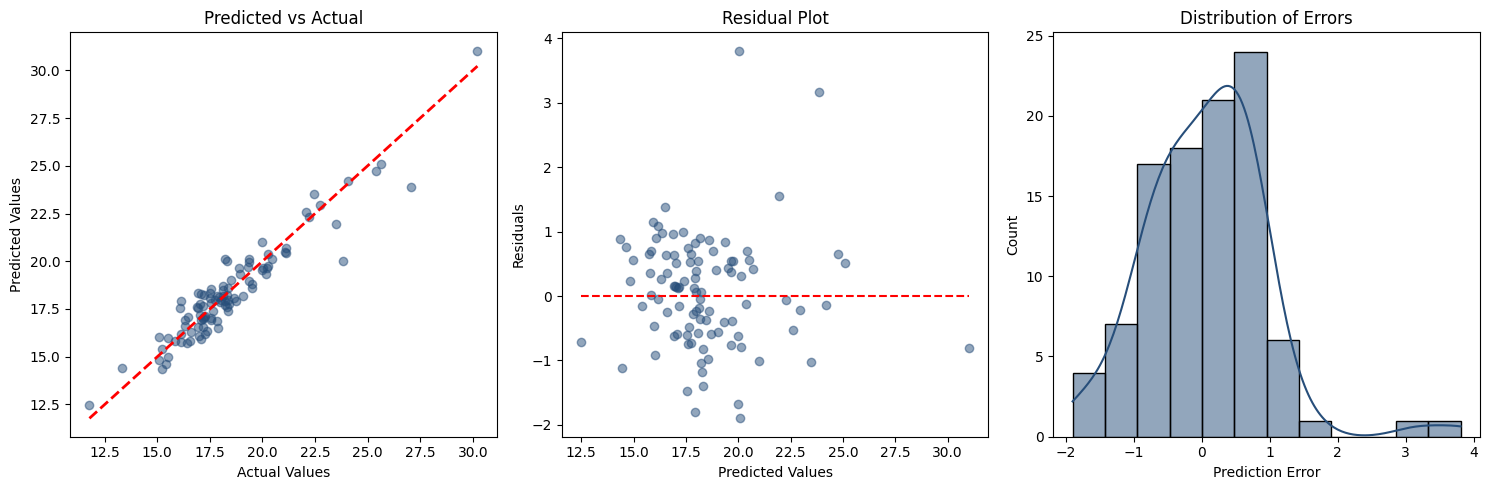

In [9]:
class PolynomialModel_simple():
    
    def __init__(self, degree=1):
        self.degree = degree
        self.params = None

    def poly_features(self, X):
        return np.hstack([X**m for m in range(self.degree + 1)])

    def fit(self, data):
        X, y = data.X, data.y
        features = self.poly_features(X)
        self.params = np.linalg.pinv(features) @ y

    def predict(self, X):
        features = self.poly_features(X)
        return features @ self.params
    
results_poly = evaluate_model_cv(PolynomialModel_simple, data_train, k=10, degree=4)
plot_for_analysis_model(results_poly["y_true"], results_poly["y_pred"])

Average MSE: 4.4522
Standard deviation of MSE: 4.6498
The RMSE: 2.2601
Average MSE: 3.4921
Standard deviation of MSE: 2.8483
The RMSE: 1.8141
Average MSE: 0.9648
Standard deviation of MSE: 0.6505
The RMSE: 0.9823
Average MSE: 0.9502
Standard deviation of MSE: 0.3142
The RMSE: 0.9692
Average MSE: 0.9443
Standard deviation of MSE: 0.1792
The RMSE: 0.9698
Average MSE: 0.6746
Standard deviation of MSE: 0.1611
The RMSE: 0.8213
Average MSE: 0.7434
Standard deviation of MSE: 0.2957
The RMSE: 0.8620
Average MSE: 0.6252
Standard deviation of MSE: 0.0671
The RMSE: 0.7900
Average MSE: 1.0736
Standard deviation of MSE: 0.3842
The RMSE: 1.0361
Average MSE: 0.8764
Standard deviation of MSE: 0.0685
The RMSE: 0.9356


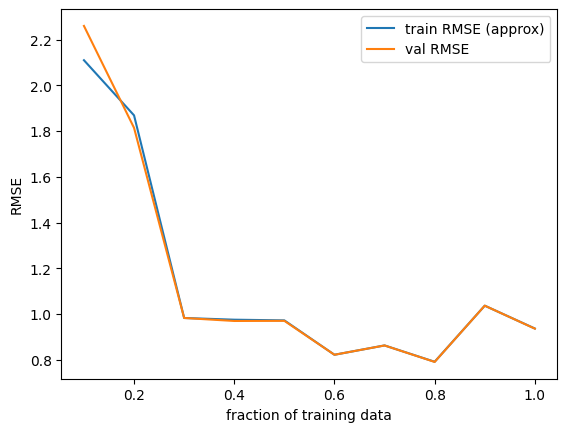

In [ ]:
def incremental_learning_curve(model_class, data, degrees=4, fractions=np.linspace(0.1,1.0,10)):
    n = len(data.y)
    train_err, val_err = [], []
    for frac in fractions:
        m = model_class(degree=degrees)
        # sample a fraction of data for training each time (shuffle)
        idx = np.random.RandomState(0).choice(n, size=int(n*frac), replace=False)
        X_sub, y_sub = data.X[idx], data.y[idx]
        # use 3-fold CV inside this sub-sample to estimate val error
        res = evaluate_model_cv(model_class, type('o',(object,),{'X':X_sub,'y':y_sub}), k=3, degree=degrees)
        train_err.append(res['mean_mse']**0.5)  # approx
        val_err.append(res['rmse'])
    return fractions, train_err, val_err

# run and plot
fract, tr_err, v_err = incremental_learning_curve(PolynomialModel_simple, data_train, degrees=4)
plt.plot(fract, tr_err, label='train RMSE (approx)')
plt.plot(fract, v_err, label='val RMSE')
plt.xlabel('fraction of training data')
plt.ylabel('RMSE')
plt.legend(); plt.show()


The simple degree-4 polynomial model achieved an RMSE of 0.88, outperforming several more complex alternatives. However, higher-degree polynomials are prone to fitting noise, which can lead to poor generalization. To prevent overfitting and improve performance on unseen test data, we explored ensembling different models. The final hybrid model was selected because it provided a better balance between bias and variance while further reducing the RMSE

#### Best model
Use the cell below to define your best model, in the form of a class called `Model`. The class must have (at least) the following two methods:
* `fit`: trains the model based on an instance of the class `Data` that is used as input argument.
* `predict`: predicts the target variable for observations with input features `X`, that is used as input argument.

For the sake of clarity, we have defined a placeholder version of the class `Model`. This placeholder version can be replaced by your best model class `Model`.

Our final model integrates three components: a robust polynomial regression with regularization, a PCA-enhanced distance-weighted KNN, and a simple polynomial baseline. By combining them through weighted ensembling, the model balances flexibility, stability, and generalization, achieving consistent performance across different regions of the target distribution.

In [23]:
model_kwargs = {
    "alpha": 5,
    "k_values": range(1, 5),
    "degree_poly": 2,
    "degree_knn": 2,
    "degree_simple": 4,
    "weight_poly": 0.6,
    "weight_knn": 0.15,
    "weight_simple": 0.25
}


In [29]:
class PolynomialModel():
    def __init__(self, **model_kwargs):
        self.degree = model_kwargs.get('degree', 2)
        self.method = model_kwargs.get('method', 'ols')   # 'ols', 'ridge', 'lasso'
        self.alpha = model_kwargs.get('alpha', 1.0)       # regularization strength
        self.max_iter = model_kwargs.get('max_iter', 1000)
        self.tol = model_kwargs.get('tol', 1e-4)
        self.scaler = model_kwargs.get('scaler', 'zscore')  # 'zscore' or 'robust'
        self.params = None
        self.mean_X = None
        self.std_X = None
        self.median_X = None
        self.iqr_X = None

    def poly_features(self, X):
        
        return np.hstack((np.ones((X.shape[0], 1)), *[X**m for m in range(1, self.degree + 1)]))

    def _scale_fit(self, X):
        if self.scaler == "zscore":
            self.mean_X = np.mean(X, axis=0)
            self.std_X = np.std(X, axis=0)
            self.std_X[self.std_X == 0] = 1.0
        elif self.scaler == "robust":
            self.median_X = np.median(X, axis=0)
            q1 = np.percentile(X, 25, axis=0)
            q3 = np.percentile(X, 75, axis=0)
            self.iqr_X = q3 - q1
            self.iqr_X[self.iqr_X == 0] = 1.0

    def _scale_transform(self, X):
        if self.scaler == "zscore":
            return (X - self.mean_X) / self.std_X
        elif self.scaler == "robust":
            return (X - self.median_X) / self.iqr_X
        else:
            return X

    def lasso_regression_numpy(self, X, y, alpha=10.0, max_iter=1000, tol=1e-4):
        n_samples, n_features = X.shape
        w = np.zeros(n_features)
        for iteration in range(max_iter):
            w_old = w.copy()
            for j in range(n_features):
                X_j = X[:, j]
                y_pred = X @ w
                residual = y - y_pred + w[j] * X_j
                rho = X_j @ residual
                z = np.sum(X_j ** 2)
                if rho < -alpha:
                    w[j] = (rho + alpha) / z
                elif rho > alpha:
                    w[j] = (rho - alpha) / z
                else:
                    w[j] = 0.0
            if np.linalg.norm(w - w_old, ord=1) < tol:
                break
        return w

    def fit(self, data):
        X, y = data.X, data.y
        y = y.flatten()

        # fit scaler
        self._scale_fit(X)
        X_scaled = self._scale_transform(X)

        # polynomial expansion
        features = self.poly_features(X_scaled)

        # choose method
        if self.method == 'ols':
            self.params = np.linalg.pinv(features) @ y
        elif self.method == 'ridge':
            self.params = self.ridge_regression_numpy(features, y, alpha=self.alpha)
        elif self.method == 'lasso':
            self.params = self.lasso_regression_numpy(features, y, alpha=self.alpha,
                                                      max_iter=self.max_iter, tol=self.tol)
        else:
            raise ValueError("method must be 'ols', 'ridge', or 'lasso'")

    def predict(self, X):
        X_scaled = self._scale_transform(X)
        features = self.poly_features(X_scaled)
        return features @ self.params
    
#=============================================================================
class PolyKNNModel_dw():
    def __init__(self, **kwargs):
        self.degree = kwargs.get('degree', 2)
        self.k_values = kwargs.get('k_values', range(1,15))
        self.n_splits = kwargs.get('n_splits', 10)
        self.n_components = kwargs.get('n_components', None) 
        self.random_state = kwargs.get('random_state', 42)
        self.best_k = None
        self.mean = None
        self.std = None
        self.X_train = None
        self.y_train = None
        self.Vt = None  
    def poly_features(self, X):
        return np.hstack((np.ones((X.shape[0], 1)), *[X**m for m in range(1, self.degree + 1)]))

    def _fit_pca(self, X):
        # SVD-based PCA
        U, S, Vt = np.linalg.svd(X, full_matrices=False)
        if self.n_components is not None:
            self.Vt = Vt[:self.n_components, :]
            return X @ self.Vt.T
        else:
            self.Vt = None
            return X

    def _transform_pca(self, X):
        if self.Vt is not None:
            return X @ self.Vt.T
        return X

    def fit(self, data):
        X, y = data.X, data.y
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)
        self.std[self.std == 0] = 1.0
        X = (X - self.mean) / self.std

        X_poly = self.poly_features(X)

        X_poly = self._fit_pca(X_poly)

        self.X_train = X_poly
        self.y_train = y

       
        best_rmse = float('inf')
        kf = KFold(n_splits=self.n_splits, shuffle=True, random_state=self.random_state)
        for k in self.k_values:
            rmse_list = []
            for train_idx, val_idx in kf.split(X_poly):
                X_tr, X_val = X_poly[train_idx], X_poly[val_idx]
                y_tr, y_val = y[train_idx], y[val_idx]

                y_val_pred = []
                for x in X_val:
                    dists = np.sqrt(np.sum((X_tr - x)**2, axis=1))
                    nn_idx = np.argsort(dists)[:k]
                   
                    weights = 1 / (dists[nn_idx] + 1e-8)
                    weights /= np.sum(weights)
                    y_val_pred.append(np.sum(weights * y_tr[nn_idx]))
                rmse = np.sqrt(np.mean((y_val - np.array(y_val_pred))**2))
                rmse_list.append(rmse)

            avg_rmse = np.mean(rmse_list)
            if avg_rmse < best_rmse:
                best_rmse = avg_rmse
                self.best_k = k

    def predict(self, X):
        
        X = (X - self.mean) / self.std
        X_poly = self.poly_features(X)
        X_poly = self._transform_pca(X_poly)

        y_pred = []
        for x in X_poly:
            dists = np.sqrt(np.sum((self.X_train - x)**2, axis=1))
            nn_idx = np.argsort(dists)[:self.best_k]
            # distance weighting
            weights = 1 / (dists[nn_idx] + 1e-8)
            weights /= np.sum(weights)
            y_pred.append(np.sum(weights * self.y_train[nn_idx]))
        return np.array(y_pred).reshape(-1,1)
    

class PolynomialModel_simple():
    
    def __init__(self, degree=1):
        self.degree = degree
        self.params = None

    def poly_features(self, X):
        return np.hstack([X**m for m in range(self.degree + 1)])

    def fit(self, data):
        X, y = data.X, data.y
        features = self.poly_features(X)
        self.params = np.linalg.pinv(features) @ y

    def predict(self, X):
        features = self.poly_features(X)
        return features @ self.params


class Model():
    def __init__(self, **model_kwargs):
        self.weight_poly = model_kwargs.get('weight_poly', 0.6)
        self.weight_knn = model_kwargs.get('weight_knn', 0.2)
        self.weight_simple = model_kwargs.get('weight_simple', 0.2)

        total = self.weight_poly + self.weight_knn + self.weight_simple
        self.weight_poly /= total
        self.weight_knn /= total
        self.weight_simple /= total

        degree_poly = model_kwargs.get('degree_poly', 2)
        degree_knn = model_kwargs.get('degree_knn', 2)
        degree_simple = model_kwargs.get('degree_simple', 4)


        alpha = model_kwargs.get('alpha', 10)
        k_values = model_kwargs.get('k_values', range(1, 5))

        self.poly_model = PolynomialModel(method="lasso", degree=degree_poly, alpha=alpha, scaler="robust")
        self.knn_model = PolyKNNModel_dw(degree=degree_knn, k_values=k_values, n_components=15)
        self.simple_model = PolynomialModel_simple(degree=degree_simple)

    def fit(self, data):
        self.poly_model.fit(data)
        self.knn_model.fit(data)
        self.simple_model.fit(data)

    def predict(self, X):
        y_pred_poly = self.poly_model.predict(X).reshape(-1,1)
        y_pred_knn  = self.knn_model.predict(X).reshape(-1,1)
        y_pred_simple = self.simple_model.predict(X).reshape(-1,1)

        return (
            self.weight_poly * y_pred_poly +
            self.weight_knn * y_pred_knn +
            self.weight_simple * y_pred_simple
        )


#### Generalization performance
The cell below computes the generalization performance of `Model` and should **NOT** be changed.

Note that the RMSE is computed twice: once on the whole test set at once, and a second time on the individual observations one-by-one. The results should be identical.

In [27]:
### DO NOT CHANGE THIS CELL. IT WILL BE USED TO TEST YOUR CUSTOM MODEL.
### CHANGING THIS CELL WILL RESULT IN POINT DEDUCTIONS.

# Load data
with open('data/data_train.pkl', 'rb') as f:
    data_train = pickle.load(f)
try:
    with open('data/data_test.pkl', 'rb') as f:
        data_test = pickle.load(f)
except FileNotFoundError:
    with open('data/data_test_FAKE.pkl', 'rb') as f:
        data_test = pickle.load(f)

# Custom model parameters
try:
    model_kwargs
except NameError:
    model_kwargs = {}

# Train custom model
model = Model(**model_kwargs)
model.fit(data_train)

# Predict on test set
y_pred = model.predict(data_test.X)
print("RMSE (default):   ", np.sqrt(np.mean((y_pred - data_test.y)**2)))

# Predict on test set (custom implementation predicting one-by-one)
errors = []
for i in range(data_test.X.shape[0]):
    y_pred = model.predict(data_test.X[i].reshape(1, -1))
    errors.append(y_pred - data_test.y[i])
print("RMSE (one-by-one):", np.sqrt(np.mean(np.array(errors)**2)))

RMSE (default):    130.79432741840296
RMSE (one-by-one): 130.794327418403


Average MSE: 0.8034
Standard deviation of MSE: 1.2464
The RMSE: 0.8963


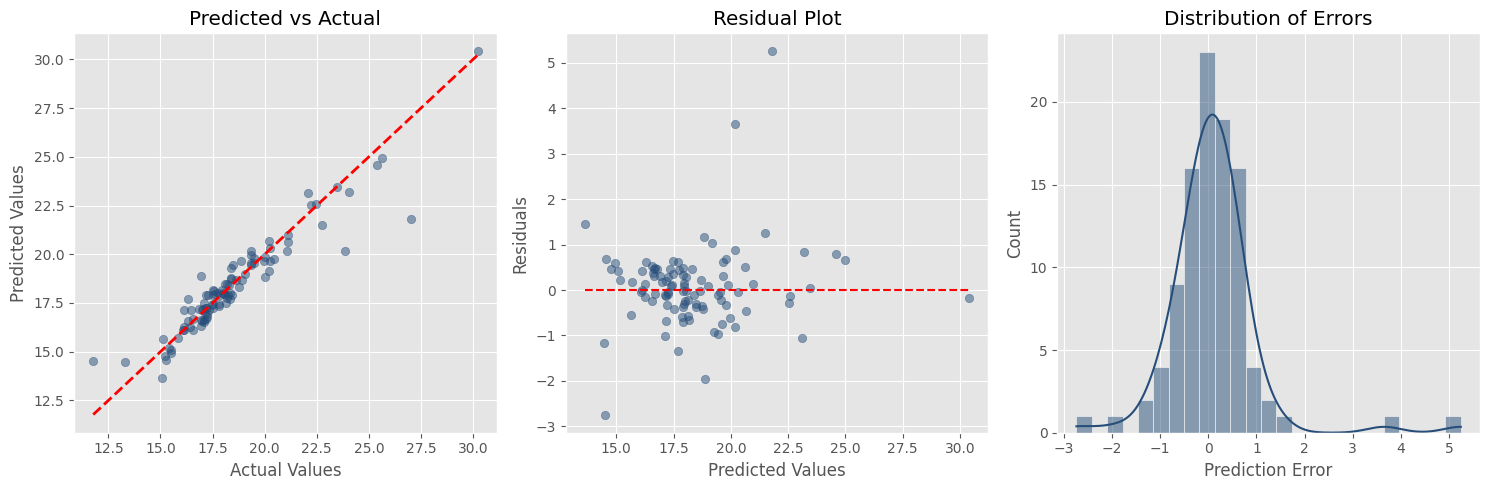

In [31]:
results = evaluate_model_cv(
    Model,
    data_train,
    k=10,
    alpha=5,
    k_values=range(1,5),
    degree_poly=2,
    degree_knn=2,
    degree_simple=4,
    weight_poly=0.6,
    weight_knn=0.15,
    weight_simple=0.25
)
plot_for_analysis_model(results["y_true"], results["y_pred"])